# MNIST Dense Network Architectures

This notebook develops dense feed-forward neural networks on MNIST from TensorFlow linear and logistic baselines to one- and two-hidden-layer models, multilayer architecture studies, hyperparameter sensitivity, and shuffled-feature experiments.



## TensorFlow Linear and Logistic Baselines

Linear and logistic models establish the TensorFlow training workflow before additional dense layers are introduced.

The tensorflow library allows flexible and very efficient implementations of models consisting of sequences of linear operations (matrix multiplication) and non-linear operations (such as sigmoid). Gradient computations are performed automatically and several optimization algorithms are provided to optimize model parameters. Several loss functions (such as mean squared error, mean absolute error, and cross entropy) are also provided.

In this notebook we will see how to implement linear and logistic regression with tensorflow.

Import libraries

In [1]:
import tensorflow as tf
import numpy as np
import os
import distutils
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

Function to plot loss and accuracy of the models during training.

In [2]:
def plot_results(history):
  fig, ax = plt.subplots()
  ax.plot(history.history['accuracy'],label = 'train')
  ax.plot(history.history['val_accuracy'],label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

Load, scale and reshape the data.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## **Linear Regression**

Model definition

In [4]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))               # A Dense layer implements the function y = Wx + b
  return model

Model creation

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

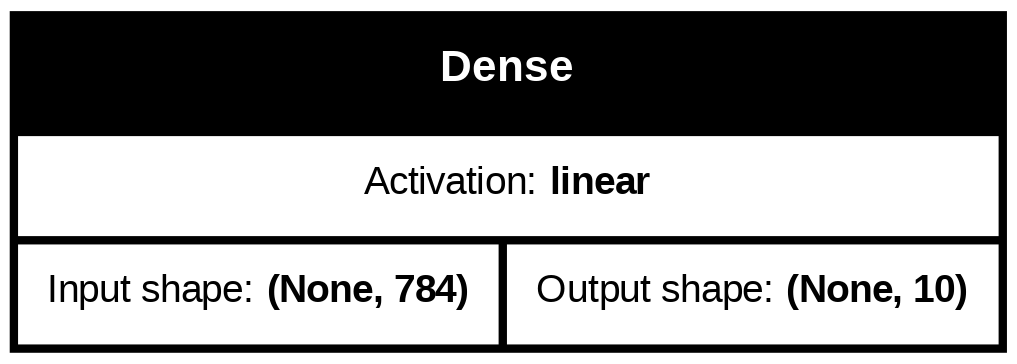

In [5]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Training the model

Epoch 1/10
60/60 - 2s - 32ms/step - accuracy: 0.5157 - loss: 0.1064 - val_accuracy: 0.7441 - val_loss: 0.0634
Epoch 2/10
60/60 - 0s - 6ms/step - accuracy: 0.7750 - loss: 0.0568 - val_accuracy: 0.8078 - val_loss: 0.0512
Epoch 3/10
60/60 - 0s - 6ms/step - accuracy: 0.8130 - loss: 0.0491 - val_accuracy: 0.8300 - val_loss: 0.0465
Epoch 4/10
60/60 - 0s - 5ms/step - accuracy: 0.8269 - loss: 0.0457 - val_accuracy: 0.8390 - val_loss: 0.0441
Epoch 5/10
60/60 - 0s - 5ms/step - accuracy: 0.8341 - loss: 0.0438 - val_accuracy: 0.8414 - val_loss: 0.0427
Epoch 6/10
60/60 - 0s - 5ms/step - accuracy: 0.8391 - loss: 0.0425 - val_accuracy: 0.8474 - val_loss: 0.0417
Epoch 7/10
60/60 - 0s - 5ms/step - accuracy: 0.8421 - loss: 0.0417 - val_accuracy: 0.8487 - val_loss: 0.0411
Epoch 8/10
60/60 - 0s - 5ms/step - accuracy: 0.8447 - loss: 0.0410 - val_accuracy: 0.8490 - val_loss: 0.0405
Epoch 9/10
60/60 - 0s - 7ms/step - accuracy: 0.8467 - loss: 0.0406 - val_accuracy: 0.8491 - val_loss: 0.0403
Epoch 10/10
60/60 

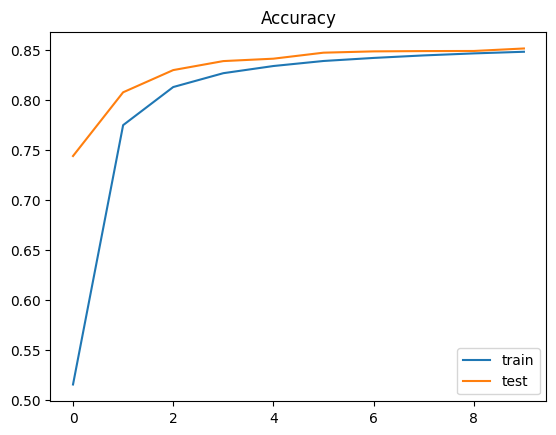

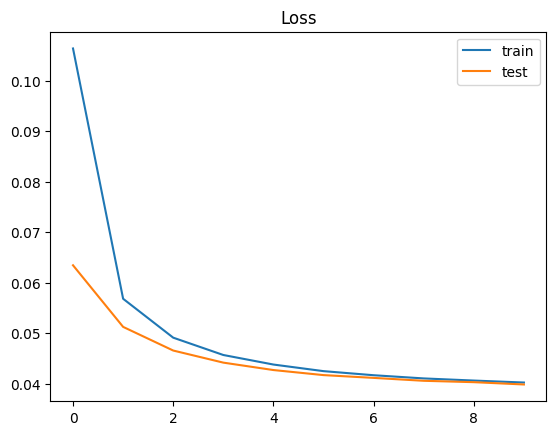

In [6]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


## **Logistic Regression**

In [7]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

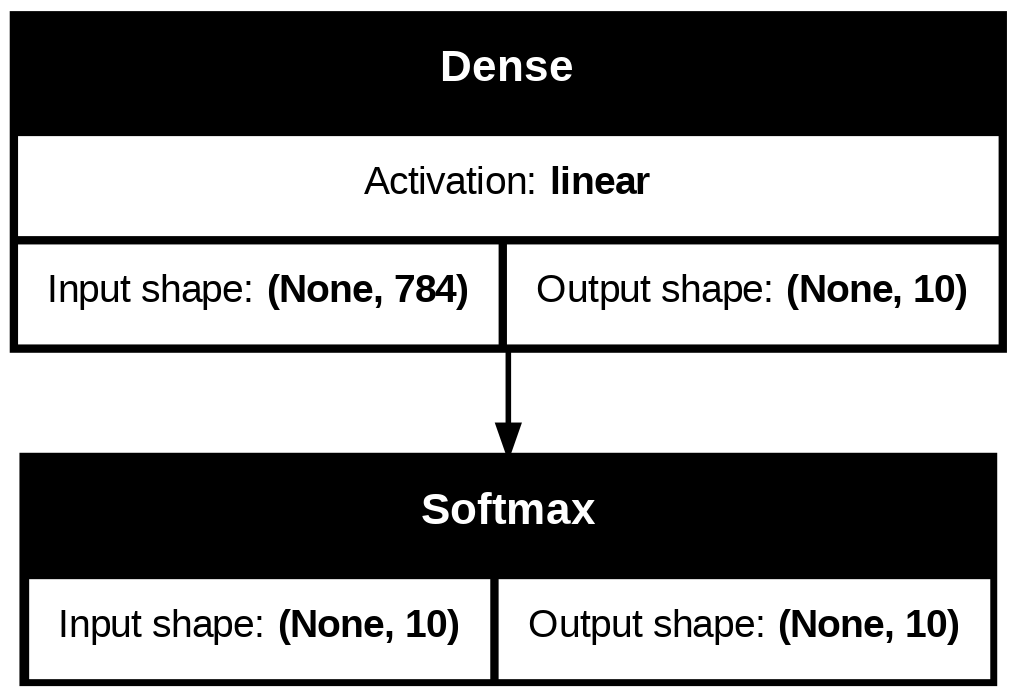

In [8]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 1s - 24ms/step - accuracy: 0.6292 - loss: 0.0592 - val_accuracy: 0.8190 - val_loss: 0.0355
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.8433 - loss: 0.0295 - val_accuracy: 0.8707 - val_loss: 0.0238
Epoch 3/40
60/60 - 0s - 5ms/step - accuracy: 0.8741 - loss: 0.0226 - val_accuracy: 0.8904 - val_loss: 0.0198
Epoch 4/40
60/60 - 0s - 5ms/step - accuracy: 0.8883 - loss: 0.0196 - val_accuracy: 0.8984 - val_loss: 0.0177
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.8968 - loss: 0.0178 - val_accuracy: 0.9045 - val_loss: 0.0163
Epoch 6/40
60/60 - 0s - 6ms/step - accuracy: 0.9021 - loss: 0.0166 - val_accuracy: 0.9090 - val_loss: 0.0154
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.9063 - loss: 0.0157 - val_accuracy: 0.9116 - val_loss: 0.0147
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.9099 - loss: 0.0151 - val_accuracy: 0.9130 - val_loss: 0.0142
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.9126 - loss: 0.0146 - val_accuracy: 0.9155 - val_loss: 0.0138
Epoch 10/40
60/60 

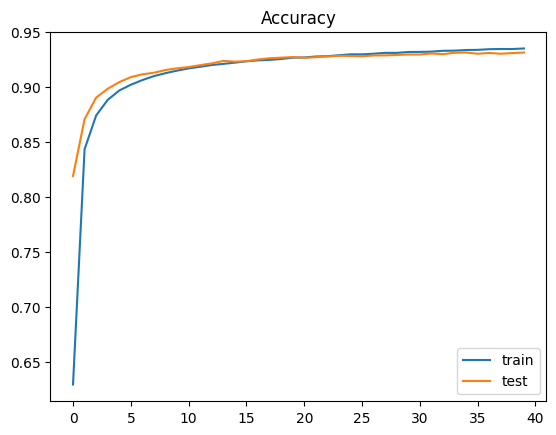

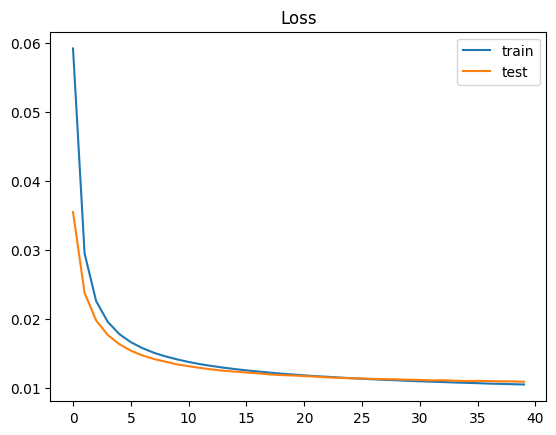

In [9]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

Replacing the loss function

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

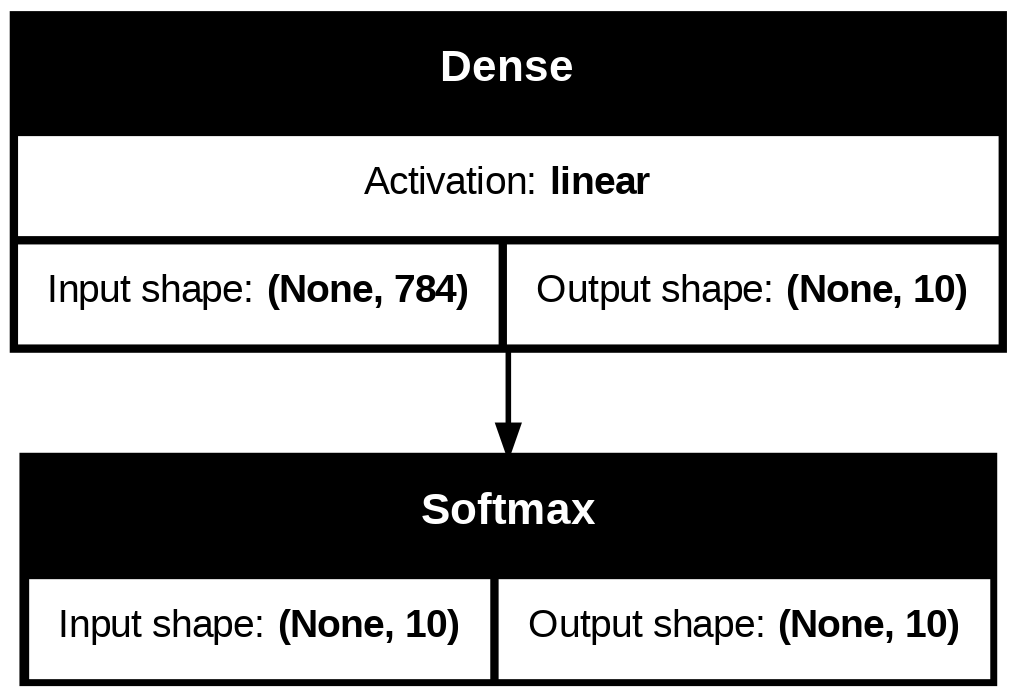

In [10]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

### Quadratic Feature Expansion

In [11]:
# Keep the original 784-feature MNIST arrays unchanged.
x_train_quad = np.hstack((x_train, x_train**2))
x_test_quad = np.hstack((x_test, x_test**2))

print("Original feature count:", x_train.shape[1])
print("Quadratic feature count:", x_train_quad.shape[1])

Original feature count: 784
Quadratic feature count: 1568


In [12]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

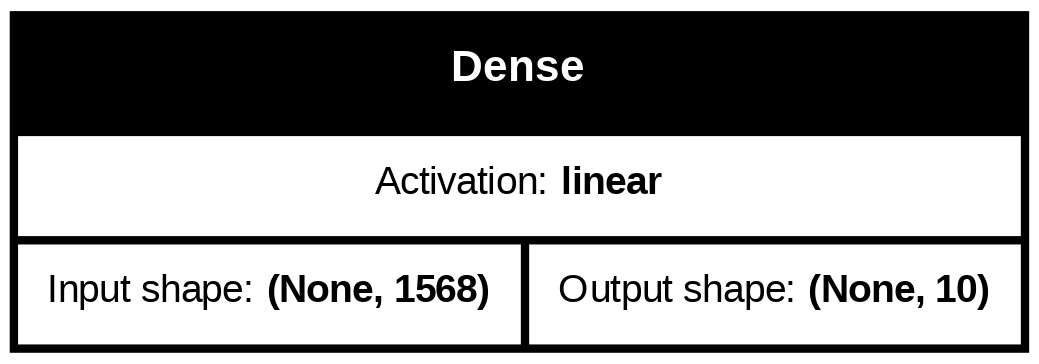

In [13]:
model = linear_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [14]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test_quad, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()

Epoch 1/10
60/60 - 2s - 28ms/step - accuracy: 0.5947 - loss: 0.0930 - val_accuracy: 0.7829 - val_loss: 0.0552
Epoch 2/10
60/60 - 0s - 6ms/step - accuracy: 0.8013 - loss: 0.0511 - val_accuracy: 0.8243 - val_loss: 0.0471
Epoch 3/10
60/60 - 0s - 7ms/step - accuracy: 0.8243 - loss: 0.0460 - val_accuracy: 0.8357 - val_loss: 0.0440
Epoch 4/10
60/60 - 0s - 6ms/step - accuracy: 0.8323 - loss: 0.0435 - val_accuracy: 0.8430 - val_loss: 0.0423
Epoch 5/10
60/60 - 0s - 6ms/step - accuracy: 0.8395 - loss: 0.0421 - val_accuracy: 0.8431 - val_loss: 0.0414
Epoch 6/10
60/60 - 0s - 6ms/step - accuracy: 0.8429 - loss: 0.0412 - val_accuracy: 0.8523 - val_loss: 0.0407
Epoch 7/10
60/60 - 0s - 6ms/step - accuracy: 0.8479 - loss: 0.0404 - val_accuracy: 0.8501 - val_loss: 0.0399
Epoch 8/10
60/60 - 0s - 6ms/step - accuracy: 0.8490 - loss: 0.0398 - val_accuracy: 0.8568 - val_loss: 0.0395
Epoch 9/10
60/60 - 1s - 11ms/step - accuracy: 0.8514 - loss: 0.0394 - val_accuracy: 0.8536 - val_loss: 0.0394
Epoch 10/10
60/60

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Elapsed time training= 6.4124 secs
Mean squared error = 0.039
Mean absolute error =  0.132
Accuracy = 0.8582
Confusion matrix
[[ 933    0    1    2    2    9   20    1   11    1]
 [   0 1109    3    2    1    1    5    2   12    0]
 [  16   64  795   25   17    0   39   24   46    6]
 [   5   23   22  857    3   13    8   25   38   16]
 [   0   27    5    1  868    2   10    2   11   56]
 [  15   18    3   62   19  640   26   19   67   23]
 [  13   11    6    0   17   20  881    0   10    0]
 [   2   44   14    5   24    2    2  874    3   58]
 [  11   55    9   20   22   32   15   11  779   20]
 [  13   11    3   13   58    0    2   51   12  846]]


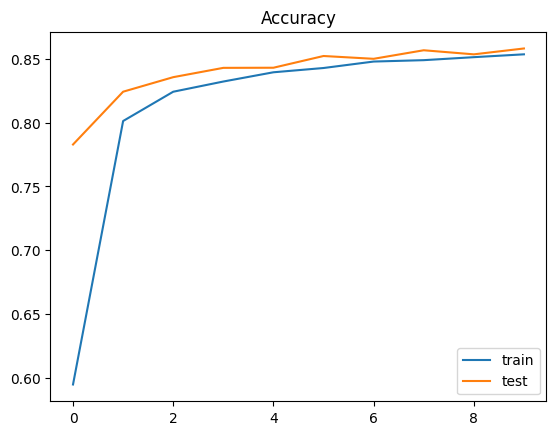

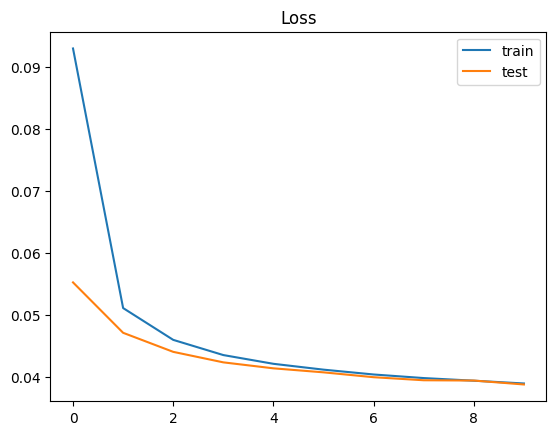

In [15]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │        15,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

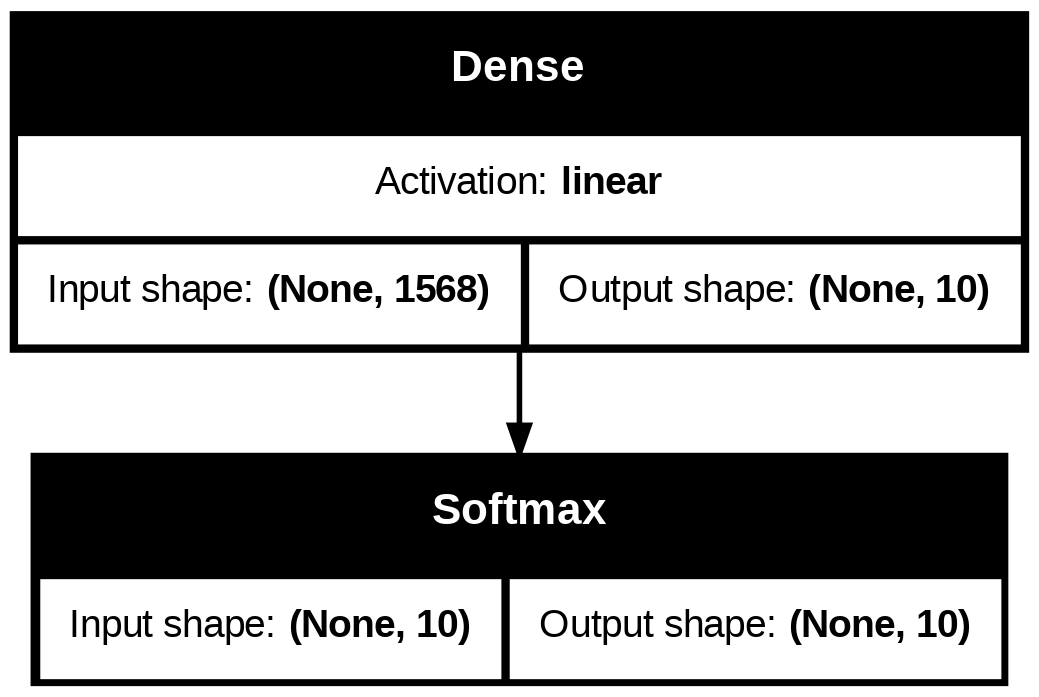

In [16]:
model = logistic_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="CategoricalCrossentropy", metrics=["accuracy"])                # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

In [17]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test_quad, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()

Epoch 1/40
60/60 - 2s - 29ms/step - accuracy: 0.7213 - loss: 1.0980 - val_accuracy: 0.8545 - val_loss: 0.6023
Epoch 2/40
60/60 - 0s - 7ms/step - accuracy: 0.8664 - loss: 0.5339 - val_accuracy: 0.8903 - val_loss: 0.4484
Epoch 3/40
60/60 - 0s - 6ms/step - accuracy: 0.8881 - loss: 0.4344 - val_accuracy: 0.9012 - val_loss: 0.3883
Epoch 4/40
60/60 - 0s - 6ms/step - accuracy: 0.8975 - loss: 0.3878 - val_accuracy: 0.9056 - val_loss: 0.3575
Epoch 5/40
60/60 - 0s - 6ms/step - accuracy: 0.9039 - loss: 0.3599 - val_accuracy: 0.9099 - val_loss: 0.3358
Epoch 6/40
60/60 - 1s - 11ms/step - accuracy: 0.9083 - loss: 0.3408 - val_accuracy: 0.9121 - val_loss: 0.3225
Epoch 7/40
60/60 - 0s - 7ms/step - accuracy: 0.9111 - loss: 0.3269 - val_accuracy: 0.9148 - val_loss: 0.3115
Epoch 8/40
60/60 - 0s - 7ms/step - accuracy: 0.9138 - loss: 0.3162 - val_accuracy: 0.9163 - val_loss: 0.3039
Epoch 9/40
60/60 - 0s - 7ms/step - accuracy: 0.9158 - loss: 0.3082 - val_accuracy: 0.9167 - val_loss: 0.2989
Epoch 10/40
60/60

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Elapsed time training= 20.7058 secs
Mean squared error = 0.011
Mean absolute error =  0.024
Accuracy = 0.9283
Confusion matrix
[[ 957    0    2    2    0    7    8    3    1    0]
 [   0 1118    3    2    0    1    4    2    5    0]
 [   4   10  929   18    8    4   11    9   35    4]
 [   2    0   20  925    0   22    2   11   22    6]
 [   1    1    4    2  918    0   11    5    9   31]
 [   7    2    2   34    8  781   16    8   27    7]
 [   8    3    6    1    7   13  917    2    1    0]
 [   1    6   24    4    5    1    0  947    3   37]
 [   6    8    6   22    8   26   11   14  864    9]
 [   9    7    1    8   24    7    0   19    7  927]]


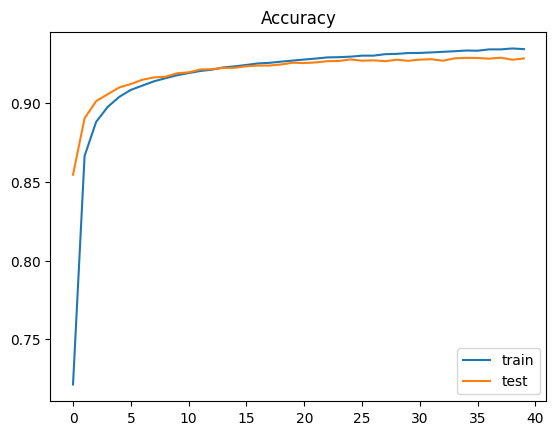

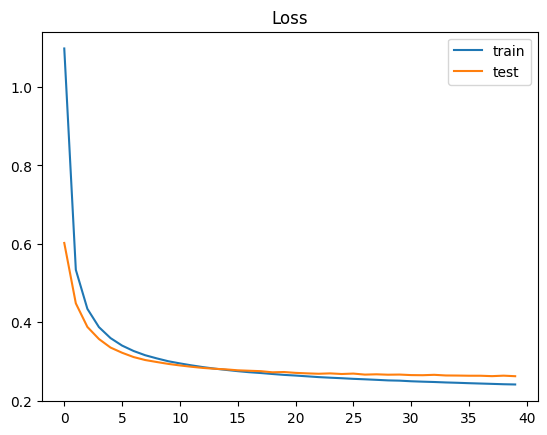

In [18]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Additional Dense Layer in the Linear Model

In [19]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  return model

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │        15,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,800 (61.72 KB)

 Trainable params: 15,800 (61.72 KB)

 Non-trainable params: 0 (0.00 B)

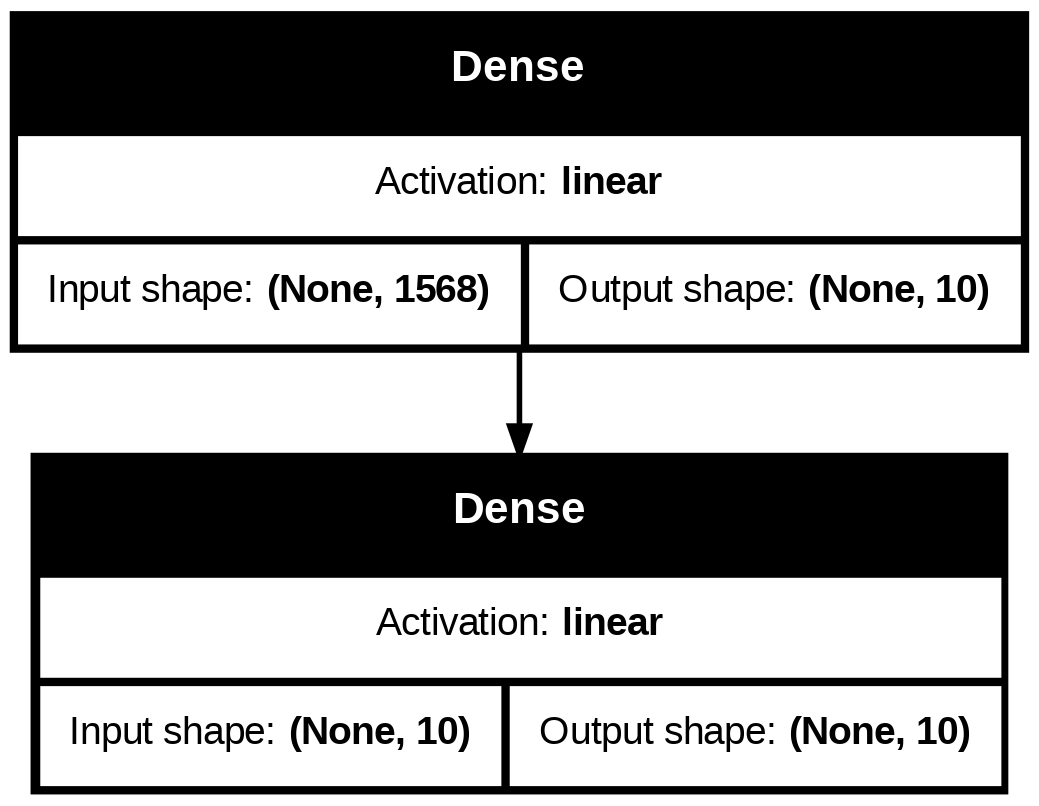

In [20]:
model = linear_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [21]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs=10,
    batch_size=1000,
    verbose=2,
    validation_data=(x_test_quad, y_test),
)
end_train = time.time()

Epoch 1/10
60/60 - 3s - 42ms/step - accuracy: 0.5638 - loss: 0.0911 - val_accuracy: 0.7678 - val_loss: 0.0556
Epoch 2/10
60/60 - 0s - 7ms/step - accuracy: 0.7954 - loss: 0.0507 - val_accuracy: 0.8257 - val_loss: 0.0464
Epoch 3/10
60/60 - 0s - 6ms/step - accuracy: 0.8237 - loss: 0.0452 - val_accuracy: 0.8369 - val_loss: 0.0436
Epoch 4/10
60/60 - 1s - 10ms/step - accuracy: 0.8335 - loss: 0.0431 - val_accuracy: 0.8501 - val_loss: 0.0418
Epoch 5/10
60/60 - 0s - 6ms/step - accuracy: 0.8402 - loss: 0.0417 - val_accuracy: 0.8470 - val_loss: 0.0411
Epoch 6/10
60/60 - 0s - 7ms/step - accuracy: 0.8436 - loss: 0.0408 - val_accuracy: 0.8529 - val_loss: 0.0401
Epoch 7/10
60/60 - 0s - 7ms/step - accuracy: 0.8466 - loss: 0.0402 - val_accuracy: 0.8549 - val_loss: 0.0397
Epoch 8/10
60/60 - 0s - 6ms/step - accuracy: 0.8503 - loss: 0.0396 - val_accuracy: 0.8583 - val_loss: 0.0394
Epoch 9/10
60/60 - 0s - 7ms/step - accuracy: 0.8517 - loss: 0.0393 - val_accuracy: 0.8598 - val_loss: 0.0389
Epoch 10/10
60/60

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 7.4080 secs
Mean squared error = 0.039
Mean absolute error =  0.133
Accuracy = 0.8634
Confusion matrix
[[ 941    0    1    2    2   13   13    1    7    0]
 [   0 1109    2    2    1    1    5    1   14    0]
 [  21   65  802   26   16    0   38   21   38    5]
 [   6   18   19  872    5   23   12   23   20   12]
 [   0   28    4    0  884    4    7    3    9   43]
 [  19   13    3   59   19  697   23   12   30   17]
 [  21    9    8    0   18   20  873    0    9    0]
 [   6   37   14    7   25    1    1  883    3   51]
 [  13   50    7   30   25   54   17   15  750   13]
 [  19   12    2   16   62    2    1   63    9  823]]


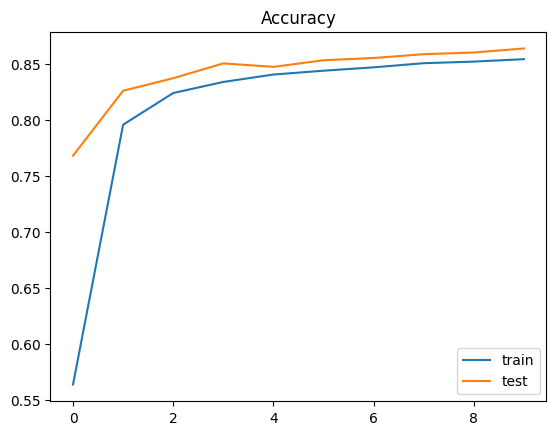

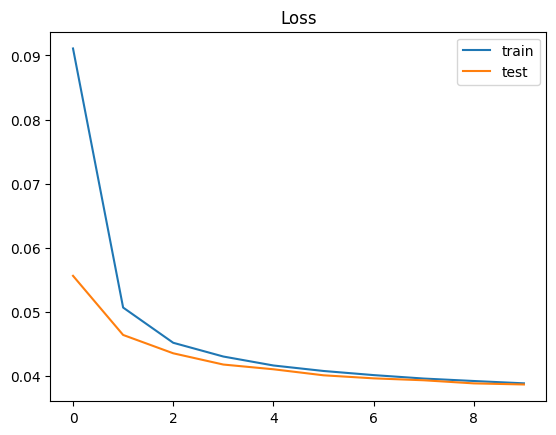

In [22]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Additional Dense and Softmax Layers

In [23]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs)) # another layer
  model.add(Dense(n_outputs))
  model.add(Softmax())
  return model

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │        15,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_3 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,800 (61.72 KB)

 Trainable params: 15,800 (61.72 KB)

 Non-trainable params: 0 (0.00 B)

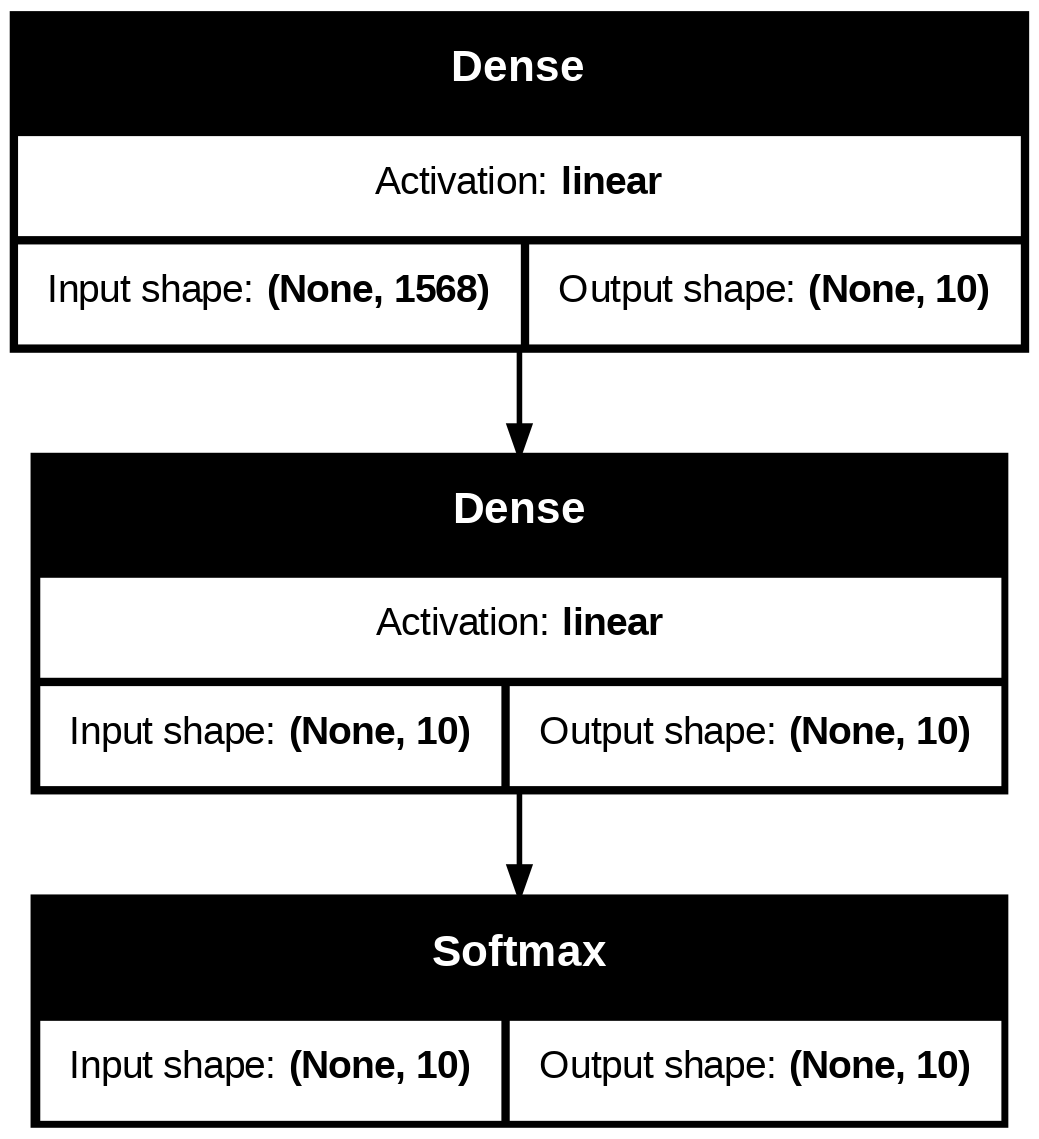

In [24]:
model = logistic_regression(x_train_quad.shape[1], y_train.shape[1])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="CategoricalCrossentropy",
    metrics=["accuracy"]
)
plot_model(
    model,
    show_shapes=True,
    show_layer_names=False,
    show_layer_activations=True
)

In [25]:
start_train = time.time()
history = model.fit(
    x_train_quad, y_train,
    epochs=40,
    batch_size=1000,
    verbose=2,
    validation_data=(x_test_quad, y_test),
)
end_train = time.time()

Epoch 1/40
60/60 - 2s - 33ms/step - accuracy: 0.6720 - loss: 1.1948 - val_accuracy: 0.8405 - val_loss: 0.6478
Epoch 2/40
60/60 - 0s - 7ms/step - accuracy: 0.8590 - loss: 0.5426 - val_accuracy: 0.8769 - val_loss: 0.4492
Epoch 3/40
60/60 - 0s - 6ms/step - accuracy: 0.8846 - loss: 0.4215 - val_accuracy: 0.8934 - val_loss: 0.3818
Epoch 4/40
60/60 - 1s - 9ms/step - accuracy: 0.8971 - loss: 0.3695 - val_accuracy: 0.9043 - val_loss: 0.3451
Epoch 5/40
60/60 - 1s - 9ms/step - accuracy: 0.9056 - loss: 0.3396 - val_accuracy: 0.9093 - val_loss: 0.3241
Epoch 6/40
60/60 - 1s - 11ms/step - accuracy: 0.9110 - loss: 0.3202 - val_accuracy: 0.9138 - val_loss: 0.3083
Epoch 7/40
60/60 - 1s - 10ms/step - accuracy: 0.9153 - loss: 0.3066 - val_accuracy: 0.9160 - val_loss: 0.2989
Epoch 8/40
60/60 - 0s - 8ms/step - accuracy: 0.9172 - loss: 0.2967 - val_accuracy: 0.9206 - val_loss: 0.2902
Epoch 9/40
60/60 - 0s - 7ms/step - accuracy: 0.9198 - loss: 0.2892 - val_accuracy: 0.9219 - val_loss: 0.2853
Epoch 10/40
60/6

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 21.6339 secs
Mean squared error = 0.011
Mean absolute error =  0.023
Accuracy = 0.9288
Confusion matrix
[[ 961    0    2    2    0    6    4    4    1    0]
 [   0 1118    4    2    0    1    3    2    5    0]
 [   5   11  937   20    8    4   10    9   23    5]
 [   2    0   21  933    1   18    3   10   16    6]
 [   1    2    6    3  917    0    8    4   10   31]
 [   9    2    3   43    9  770   12    7   30    7]
 [  11    3   10    1    7   17  907    1    1    0]
 [   1    5   24    8    5    1    0  946    2   36]
 [   7    9    8   27    7   19    8   11  870    8]
 [   9    8    1   13   24    5    0   16    4  929]]


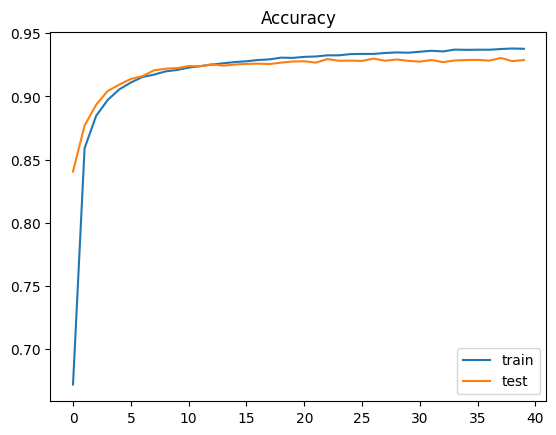

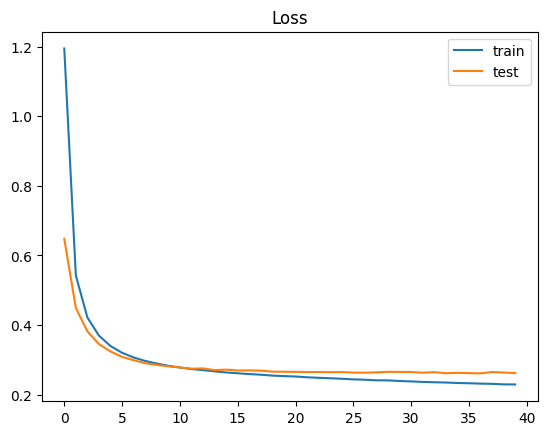

In [26]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

In [27]:
x_train_quad.shape

(60000, 1568)

## Two-Layer Linear and Nonlinear Networks

These experiments test whether adding another layer and changing activation/loss choices improves classification.

### MNIST Input Preparation

This architecture study uses the original flattened 28 × 28 MNIST input, giving 784 features per image.

In [28]:
# Prepare the original 784-feature MNIST representation for this architecture study.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = np.float32(x_train / 255).reshape(x_train.shape[0], -1)
x_test = np.float32(x_test / 255).reshape(x_test.shape[0], -1)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training input shape:", x_train.shape)
print("Test input shape:", x_test.shape)

Training input shape: (60000, 784)
Test input shape: (10000, 784)


### Specified Dense-Network Configuration

A 500-unit ReLU hidden layer is specified with stochastic gradient descent, learning rate 0.1, momentum 0.95, 30 epochs, and batch size 50, together with overall and class-level evaluation. The implementation sequence that follows uses the MNIST dataset loader present in the code.

In [29]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')

## **Linear Regression with two layers**

In [30]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,))) # A Dense layer implements the function y = Wx + b
  model.add(Dense(n_outputs)) # A Dense layer implements the function y = Wx + b
  return model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Elapsed time training= 21.6339 secs
Mean squared error = 0.011
Mean absolute error =  0.023
Accuracy = 0.9288
Confusion matrix
[[ 961    0    2    2    0    6    4    4    1    0]
 [   0 1118    4    2    0    1    3    2    5    0]
 [   5   11  937   20    8    4   10    9   23    5]
 [   2    0   21  933    1   18    3   10   16    6]
 [   1    2    6    3  917    0    8    4   10   31]
 [   9    2    3   43    9  770   12    7   30    7]
 [  11    3   10    1    7   17  907    1    1    0]
 [   1    5   24    8    5    1    0  946    2   36]
 [   7    9    8   27    7   19    8   11  870    8]
 [   9    8    1   13   24    5    0   16    4  929]]


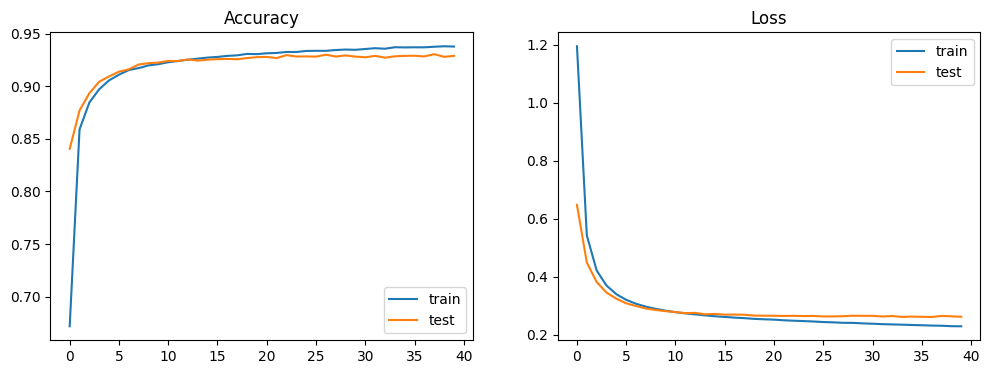

In [31]:
plot_results(history)
pred = model.predict(x_test_quad)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int,np.argmax(y_test,axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

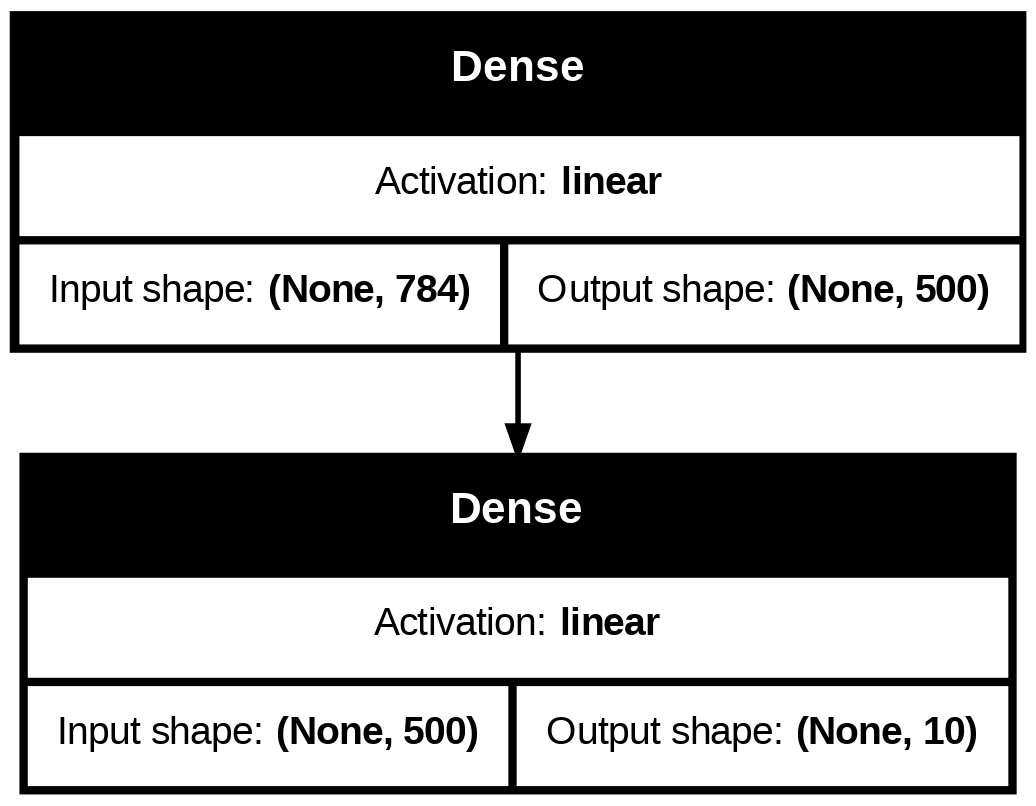

In [32]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
opt = tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"]) # Specify optimizer and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Epoch 1/40
600/600 - 3s - 5ms/step - accuracy: 0.7750 - loss: 0.0583 - val_accuracy: 0.8399 - val_loss: 0.0439
Epoch 2/40
600/600 - 2s - 4ms/step - accuracy: 0.8377 - loss: 0.0435 - val_accuracy: 0.8473 - val_loss: 0.0416
Epoch 3/40
600/600 - 2s - 4ms/step - accuracy: 0.8443 - loss: 0.0417 - val_accuracy: 0.8541 - val_loss: 0.0404
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.8463 - loss: 0.0408 - val_accuracy: 0.8540 - val_loss: 0.0397
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.8486 - loss: 0.0403 - val_accuracy: 0.8553 - val_loss: 0.0399
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.8494 - loss: 0.0400 - val_accuracy: 0.8576 - val_loss: 0.0396
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.8508 - loss: 0.0398 - val_accuracy: 0.8596 - val_loss: 0.0393
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.8510 - loss: 0.0397 - val_accuracy: 0.8574 - val_loss: 0.0393
Epoch 9/40
600/600 - 3s - 4ms/step - accuracy: 0.8503 - loss: 0.0396 - val_accuracy: 0.8487 - val_loss: 0.0394
E

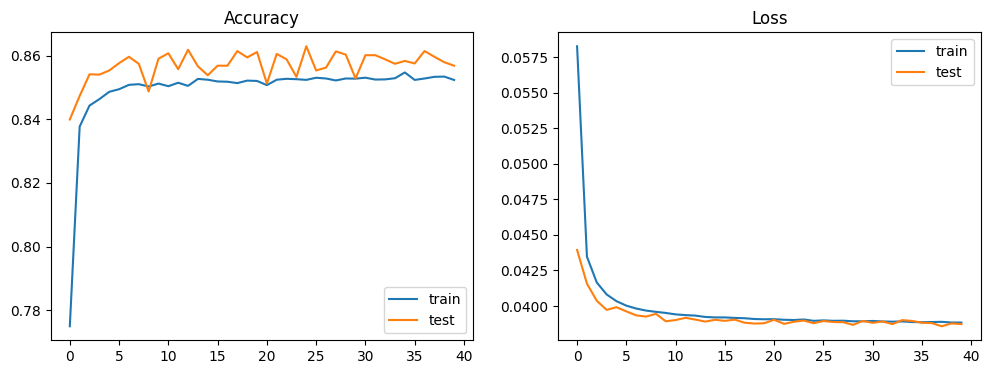

In [33]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


## **Logistic Regression with two layers**

In [34]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,), activation='sigmoid'))
  model.add(Dense(n_outputs, activation='softmax'))
  return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

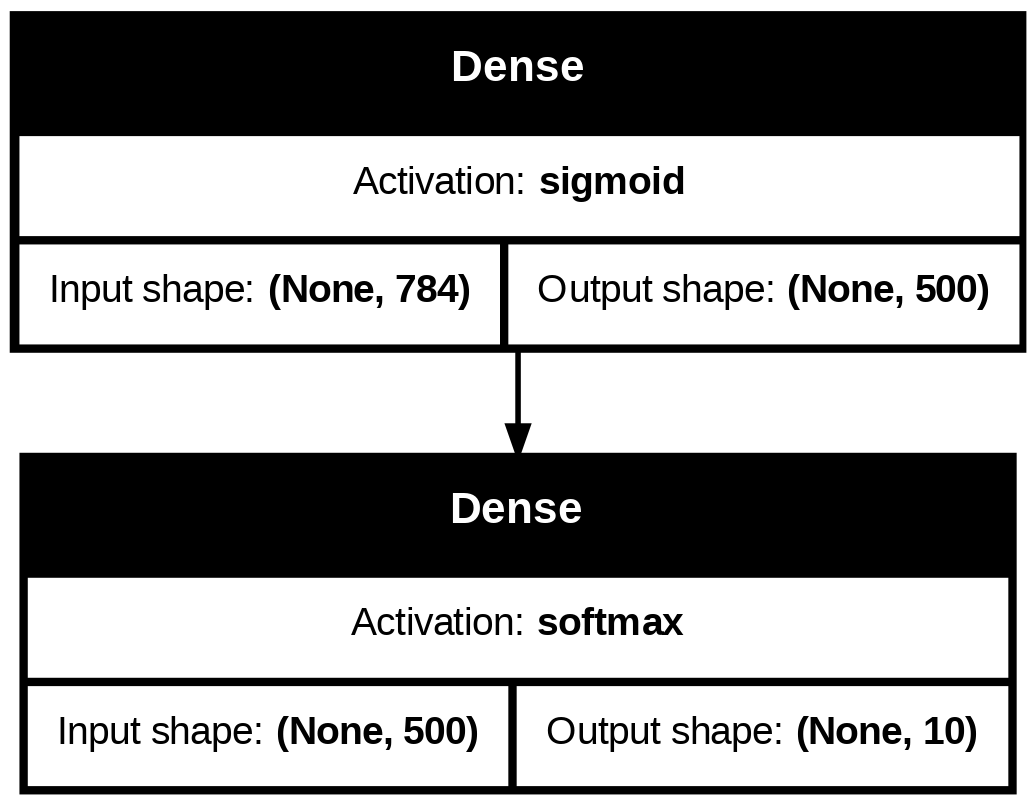

In [35]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 4s - 7ms/step - accuracy: 0.7283 - loss: 0.0425 - val_accuracy: 0.8870 - val_loss: 0.0194
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.8894 - loss: 0.0179 - val_accuracy: 0.9045 - val_loss: 0.0152
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.9022 - loss: 0.0154 - val_accuracy: 0.9107 - val_loss: 0.0138
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9086 - loss: 0.0142 - val_accuracy: 0.9147 - val_loss: 0.0130
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.9144 - loss: 0.0134 - val_accuracy: 0.9174 - val_loss: 0.0126
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.9173 - loss: 0.0130 - val_accuracy: 0.9211 - val_loss: 0.0122
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.9186 - loss: 0.0126 - val_accuracy: 0.9221 - val_loss: 0.0120
Epoch 8/40
600/600 - 3s - 4ms/step - accuracy: 0.9213 - loss: 0.0122 - val_accuracy: 0.9227 - val_loss: 0.0119
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.9227 - loss: 0.0120 - val_accuracy: 0.9254 - val_loss: 0.0116
E

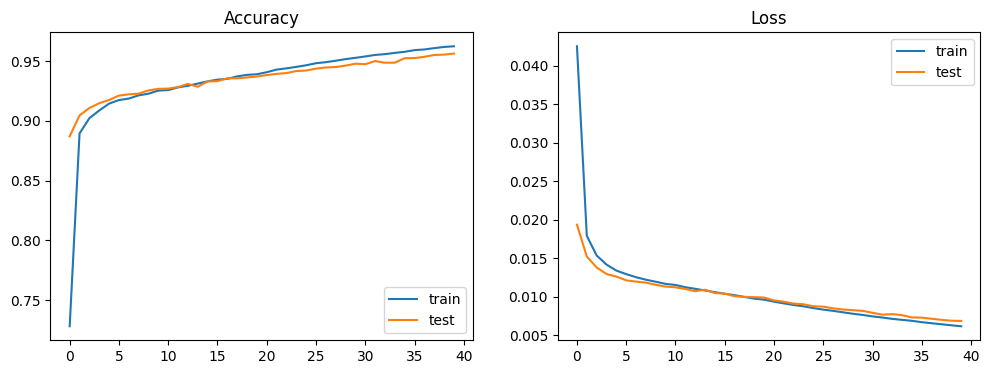

In [36]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### **Using cross-entropy loss.** Replacing the loss function by categorical cross entropy, where $y_{i,c} = 1 $ if example $i$ belongs to class $c$ and $y_{i,c} = 0 $ otherwise and  $p_{i,c}  $ is the corresponding prediction made by the network.

$$c(y_i,p_i) = -\sum_{c=1}^My_{i,c}\log(p_{i,c})$$

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

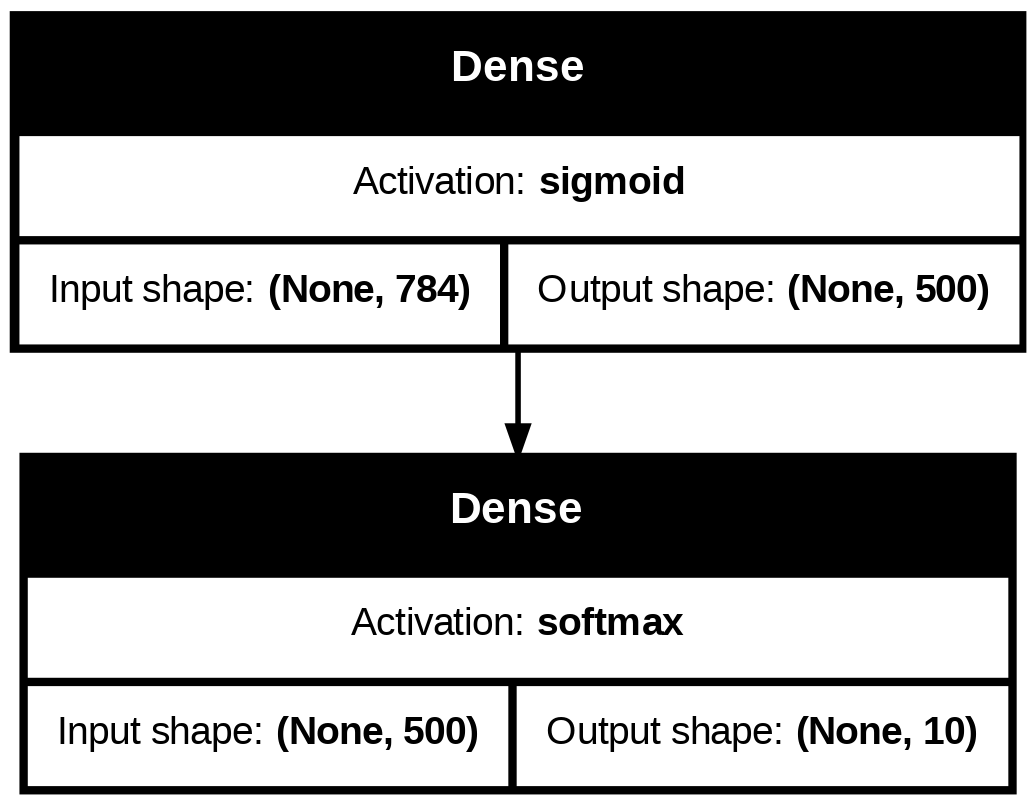

In [37]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 4s - 6ms/step - accuracy: 0.8684 - loss: 0.4992 - val_accuracy: 0.9436 - val_loss: 0.1874
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.9529 - loss: 0.1565 - val_accuracy: 0.9624 - val_loss: 0.1243
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.9677 - loss: 0.1106 - val_accuracy: 0.9685 - val_loss: 0.1045
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9744 - loss: 0.0868 - val_accuracy: 0.9732 - val_loss: 0.0861
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.9786 - loss: 0.0720 - val_accuracy: 0.9747 - val_loss: 0.0866
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.9824 - loss: 0.0603 - val_accuracy: 0.9763 - val_loss: 0.0770
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.9851 - loss: 0.0514 - val_accuracy: 0.9773 - val_loss: 0.0776
Epoch 8/40
600/600 - 2s - 4ms/step - accuracy: 0.9876 - loss: 0.0436 - val_accuracy: 0.9805 - val_loss: 0.0671
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.9894 - loss: 0.0373 - val_accuracy: 0.9781 - val_loss: 0.0706
E

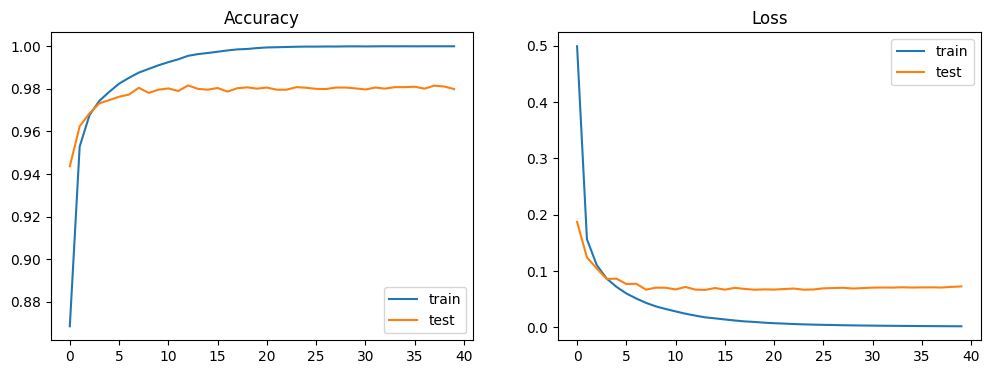

In [38]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


### **Using ReLU activation function**

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

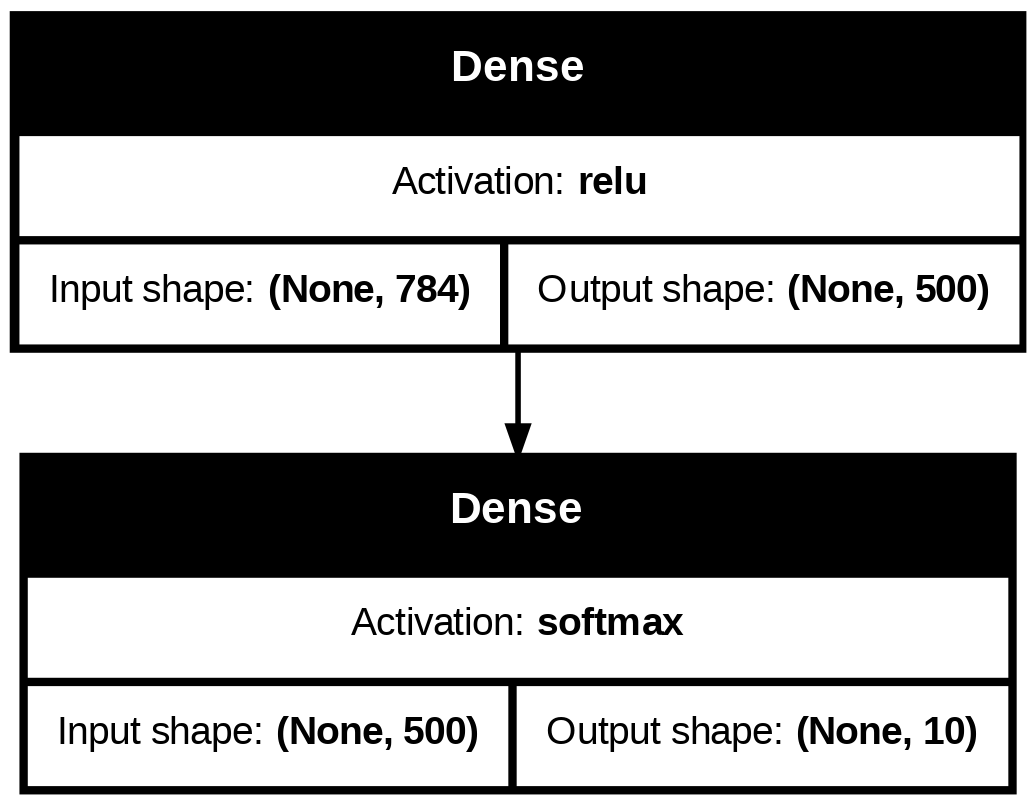

In [39]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape=(n_inputs,), activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  return model

model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 4s - 6ms/step - accuracy: 0.9361 - loss: 0.2107 - val_accuracy: 0.9660 - val_loss: 0.1121
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.9711 - loss: 0.0938 - val_accuracy: 0.9670 - val_loss: 0.1133
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.9785 - loss: 0.0675 - val_accuracy: 0.9661 - val_loss: 0.1055
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9848 - loss: 0.0476 - val_accuracy: 0.9761 - val_loss: 0.0850
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.9876 - loss: 0.0381 - val_accuracy: 0.9755 - val_loss: 0.0867
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9794 - val_loss: 0.0845
Epoch 7/40
600/600 - 2s - 4ms/step - accuracy: 0.9927 - loss: 0.0229 - val_accuracy: 0.9761 - val_loss: 0.0912
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.9943 - loss: 0.0170 - val_accuracy: 0.9804 - val_loss: 0.0795
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.9964 - loss: 0.0105 - val_accuracy: 0.9804 - val_loss: 0.0858
E

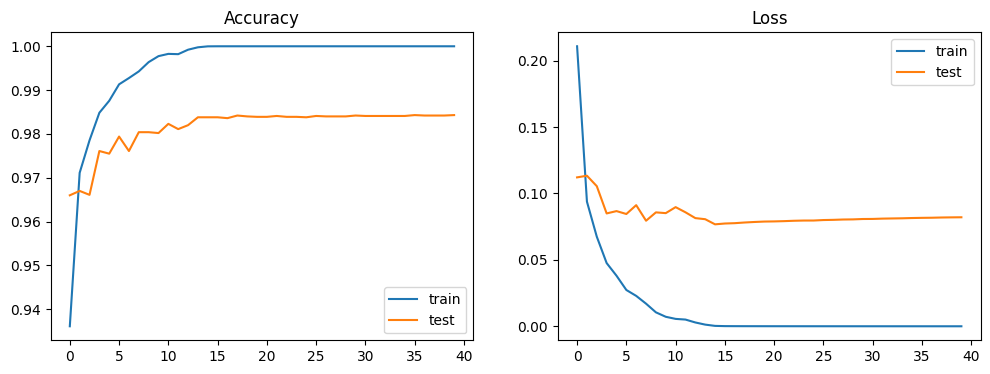

In [40]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=100,
    verbose=2,
    validation_data=(x_test, y_test),
)
end_train = time.time()

plot_results(history)
pred = model.predict(x_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(pred_int, np.argmax(y_test, axis=1))
))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test, axis=1), pred_int))

## One- and Two-Hidden-Layer MNIST Models

MNIST classification is extended from linear and logistic baselines to dense networks with one and two hidden layers. Distinct implementation variants and evaluations are retained.

## MNIST Classification Study

The following TensorFlow experiments train and evaluate multiple classification approaches on MNIST. Model assessment includes training and test accuracy together with test-set confusion matrices.

### Data Loading and Preprocessing

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

In [42]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

In [43]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)
y_train.shape=(60000,)
y_test.shape=(10000,)


Class: 7


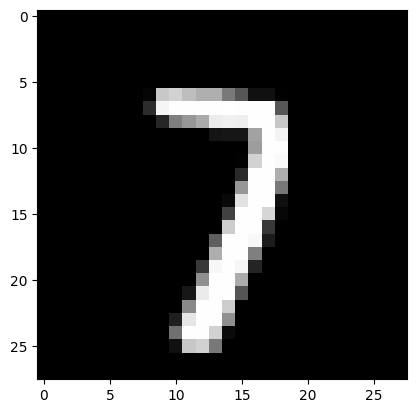

000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 005 200 210 190 175 175 121 086 016 016 001 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 045 245 254 254 254 254 255 254 254 254 086 000 000 000 000 000 000 000 000 000 
000 000 000 000 000 000 000 000 000 038 127 151 171 236 240 239 254 254 199 000 000 000 000 000 

In [44]:
im = np.random.randint(0,X_train.shape[0])
plt.imshow(X_train[im],cmap='gray')
print('Class:',y_train[im])
plt.show()

for i in range(28):
    for j in range(28):
        print(str(np.int16(X_train[im,i,j])+1000)[1:],end=' ')
    print()

### Additional MNIST Examples

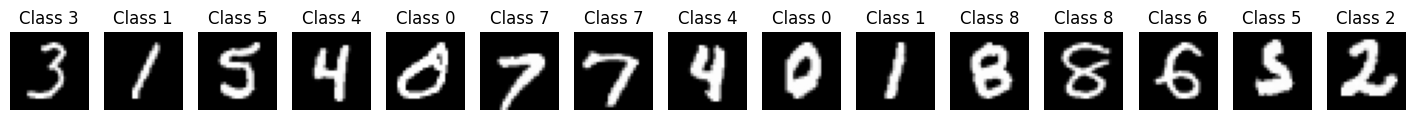

In [45]:
nimgs = 15
sel = np.random.randint(0,X_train.shape[0],size =nimgs)
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s],cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

## Pre-processing

We convert the 3D train and test datasets to 2D arrays by concatenating all pixel values in an image to a single row. We also convert to floating point. We convert the class to a one_hot representation (i.e. 1 becomes [0,1,0,0,0,0,0,0,0,0]).

In [46]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')


X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


## Linear Classification Baseline

**Creating the model**

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

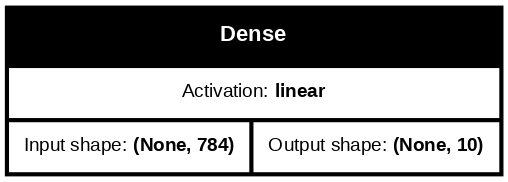

In [47]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

model = linear_regression(X_train.shape[1], y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training the model**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Elapsed time training= 6.8106 secs
Accuracy = 0.8419


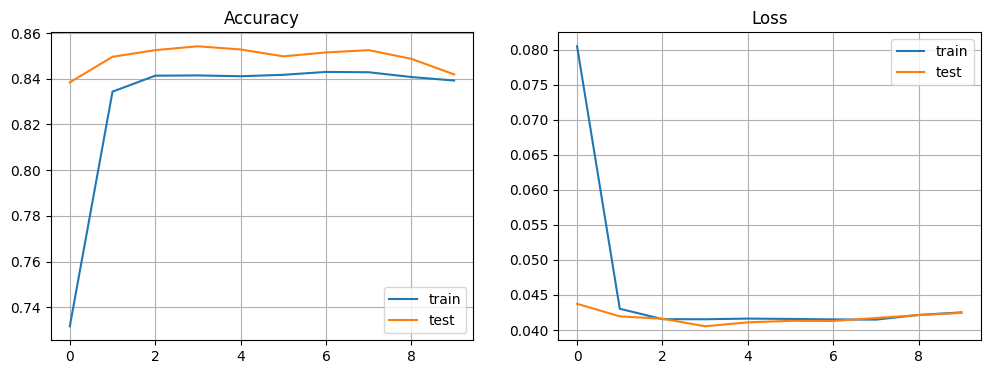

In [48]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 0,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

In [49]:
print(np.argmax(history.history['val_accuracy']))
print(np.argmin(history.history['val_loss']))
print(np.argmax(history.history['accuracy']))
print(np.argmin(history.history['loss']))

3
3
6
7


## Logistic Classification Baseline

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

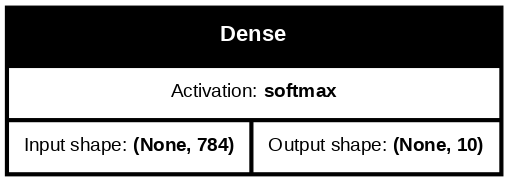

In [50]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/10
120/120 - 2s - 14ms/step - accuracy: 0.8714 - loss: 0.4514 - val_accuracy: 0.9162 - val_loss: 0.3010
Epoch 2/10
120/120 - 0s - 4ms/step - accuracy: 0.9175 - loss: 0.2957 - val_accuracy: 0.9214 - val_loss: 0.2840
Epoch 3/10
120/120 - 1s - 4ms/step - accuracy: 0.9223 - loss: 0.2775 - val_accuracy: 0.9223 - val_loss: 0.2739
Epoch 4/10
120/120 - 0s - 4ms/step - accuracy: 0.9251 - loss: 0.2692 - val_accuracy: 0.9276 - val_loss: 0.2718
Epoch 5/10
120/120 - 0s - 4ms/step - accuracy: 0.9262 - loss: 0.2646 - val_accuracy: 0.9244 - val_loss: 0.2700
Epoch 6/10
120/120 - 1s - 5ms/step - accuracy: 0.9293 - loss: 0.2579 - val_accuracy: 0.9245 - val_loss: 0.2716
Epoch 7/10
120/120 - 1s - 6ms/step - accuracy: 0.9284 - loss: 0.2567 - val_accuracy: 0.9258 - val_loss: 0.2699
Epoch 8/10
120/120 - 1s - 10ms/step - accuracy: 0.9301 - loss: 0.2543 - val_accuracy: 0.9240 - val_loss: 0.2752
Epoch 9/10
120/120 - 0s - 4ms/step - accuracy: 0.9298 - loss: 0.2530 - val_accuracy: 0.9264 - val_loss: 0.2713

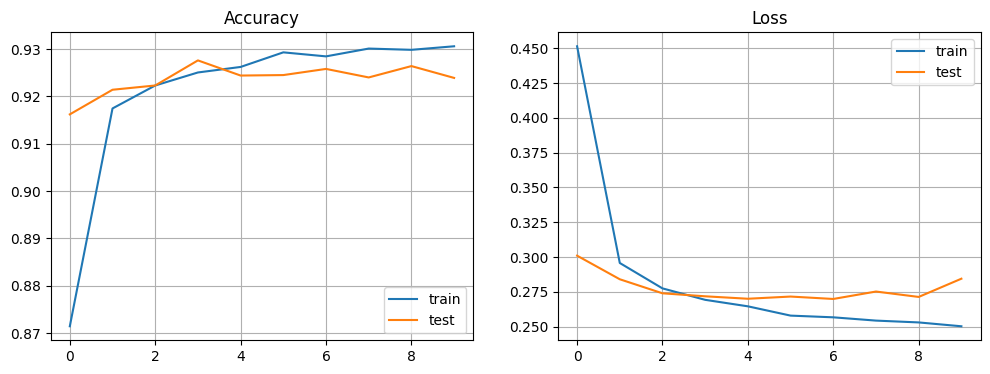

In [51]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

## Dense Network with One Hidden Layer

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

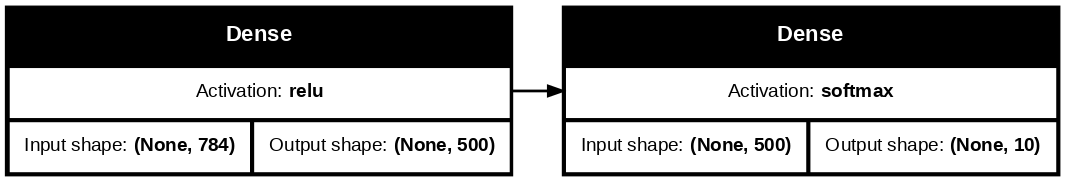

In [52]:
def ffnn_one_HL(n_inputs, hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = ffnn_one_HL(X_train.shape[1], 500,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training and evaluation**

Epoch 1/10
120/120 - 2s - 18ms/step - accuracy: 0.9183 - loss: 0.2683 - val_accuracy: 0.9657 - val_loss: 0.1139
Epoch 2/10
120/120 - 1s - 4ms/step - accuracy: 0.9739 - loss: 0.0869 - val_accuracy: 0.9718 - val_loss: 0.0865
Epoch 3/10
120/120 - 1s - 5ms/step - accuracy: 0.9805 - loss: 0.0622 - val_accuracy: 0.9743 - val_loss: 0.0823
Epoch 4/10
120/120 - 1s - 4ms/step - accuracy: 0.9861 - loss: 0.0419 - val_accuracy: 0.9764 - val_loss: 0.0807
Epoch 5/10
120/120 - 1s - 4ms/step - accuracy: 0.9888 - loss: 0.0339 - val_accuracy: 0.9768 - val_loss: 0.0783
Epoch 6/10
120/120 - 0s - 4ms/step - accuracy: 0.9905 - loss: 0.0278 - val_accuracy: 0.9749 - val_loss: 0.0964
Epoch 7/10
120/120 - 0s - 4ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9768 - val_loss: 0.0886
Epoch 8/10
120/120 - 0s - 4ms/step - accuracy: 0.9923 - loss: 0.0214 - val_accuracy: 0.9805 - val_loss: 0.0761
Epoch 9/10
120/120 - 0s - 4ms/step - accuracy: 0.9933 - loss: 0.0197 - val_accuracy: 0.9785 - val_loss: 0.0951


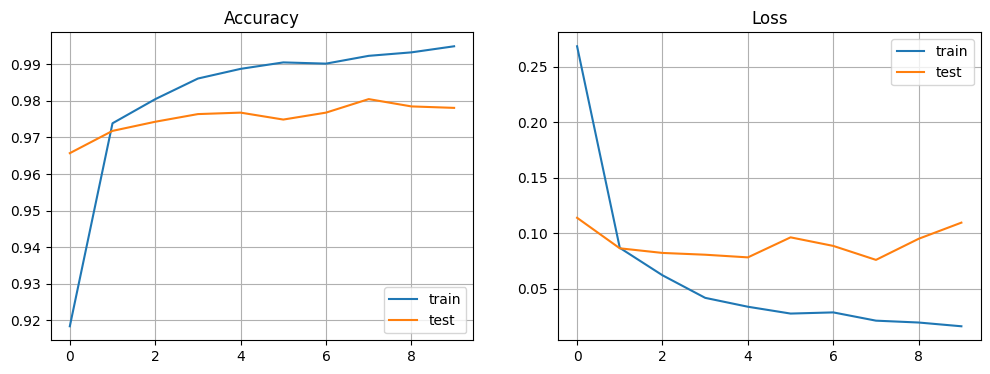

In [53]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()

plot_results(history)
pred = model.predict(X_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(y_test, np.argmax(pred, axis=1))
))

## Dense Network with Two Hidden Layers

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

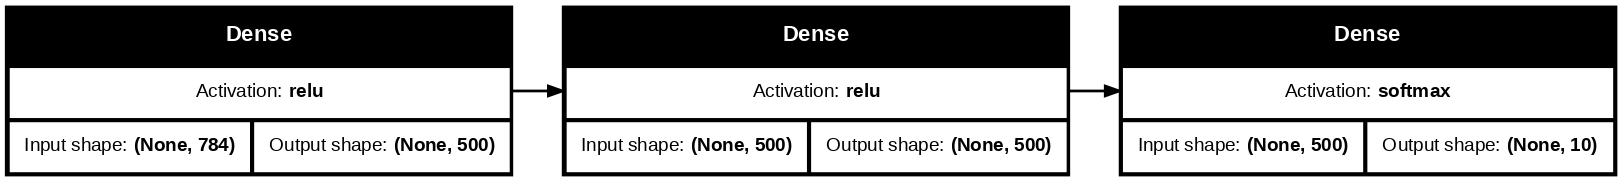

In [54]:
def ffnn_two_HL(n_inputs, hidden1, hidden2, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden1,activation='relu'))
  model.add(Dense(hidden2,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = ffnn_two_HL(X_train.shape[1], 500, 500, y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy",  metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

**Training and evaluation**

Epoch 1/10
120/120 - 3s - 24ms/step - accuracy: 0.8937 - loss: 0.3839 - val_accuracy: 0.9628 - val_loss: 0.1220
Epoch 2/10
120/120 - 0s - 4ms/step - accuracy: 0.9677 - loss: 0.1049 - val_accuracy: 0.9644 - val_loss: 0.1151
Epoch 3/10
120/120 - 1s - 4ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.9714 - val_loss: 0.0947
Epoch 4/10
120/120 - 1s - 4ms/step - accuracy: 0.9793 - loss: 0.0649 - val_accuracy: 0.9713 - val_loss: 0.0951
Epoch 5/10
120/120 - 1s - 4ms/step - accuracy: 0.9813 - loss: 0.0573 - val_accuracy: 0.9716 - val_loss: 0.0995
Epoch 6/10
120/120 - 1s - 4ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9719 - val_loss: 0.0986
Epoch 7/10
120/120 - 1s - 4ms/step - accuracy: 0.9867 - loss: 0.0422 - val_accuracy: 0.9699 - val_loss: 0.1220
Epoch 8/10
120/120 - 1s - 4ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.9680 - val_loss: 0.1285
Epoch 9/10
120/120 - 1s - 4ms/step - accuracy: 0.9900 - loss: 0.0327 - val_accuracy: 0.9674 - val_loss: 0.1476


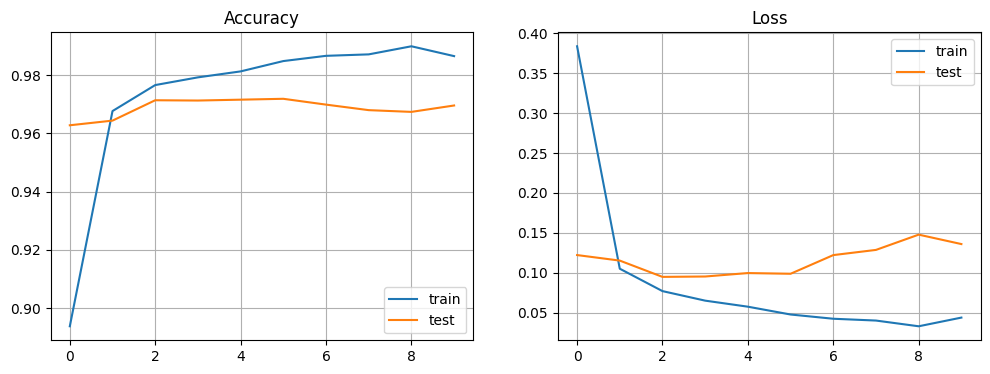

In [55]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=500,
    verbose=2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()

plot_results(history)
pred = model.predict(X_test)

print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred, axis=1)
print('Accuracy = {:.4f}'.format(
    accuracy_score(y_test, np.argmax(pred, axis=1))
))

# Some considerations for building and training neural networks

**The network's architecture**
*   Number, type and size of every layer. Networks with more parameters tend to overfit, networks with fewer parameters tend to underfit.
*   Activation functions - *relu* works well for hidden layers, *softmax* for output in multiclass classification, *sigmoid* for binary classification
*   Loss functions - *MSE* for regression, *categorical cross entropy* for multiclass classification, *binary cross entropy* for binary classification

**The training process**
*   Choice of optimizer - *Adam* works well for most problems
*   Learning rate - start with default value, try increasing and decreasing by a factor of 10
*   Batch size - smaller batches usually result in better accuracy for the same number of epochs, larger batches usually result in shorter running times for the same number of epochs.
*   Training for more epochs may lead to overfitting, training for fewer epochs may lead to underfitting

In [56]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [57]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(60000, 28, 28)
X_test.shape=(10000, 28, 28)
y_train.shape=(60000,)
y_test.shape=(10000,)


Class: 1


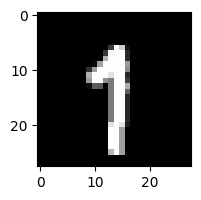

Class: 4


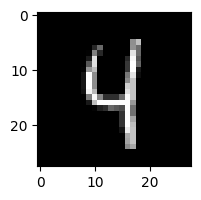

Class: 4


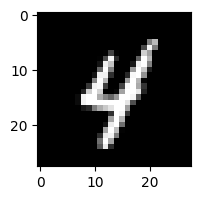

Class: 7


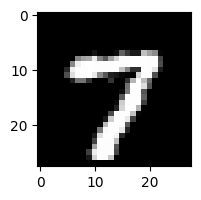

Class: 9


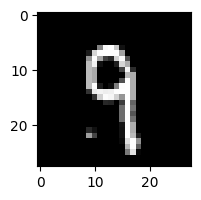

In [58]:
for i in range(5):
  im = np.random.randint(0,X_train.shape[0])
  plt.figure(figsize=(2,2))
  plt.imshow(X_train[im],cmap='gray')
  print('Class:',y_train[im])
  plt.show()

We convert the 3D train and test datasets to 2D arrays by concatenating all pixels values in an image to a single row. We also convert to floating point. We convert the class to a one_hot representation (i.e. 1 becomes [0,1,0,0,0,0,0,0,0,0]).

In [59]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


In [60]:
import os
import distutils
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

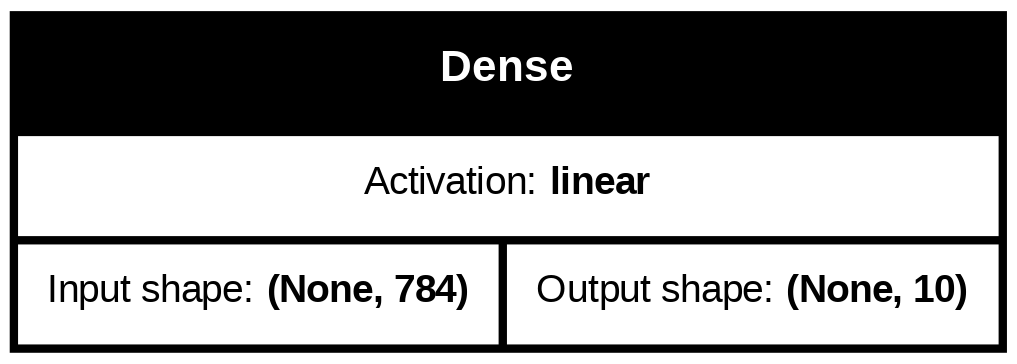

In [61]:
model = linear_regression(X_train.shape[1], y_train_oh.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
model.compile(optimizer=tf.keras.optimizers.Adam(),  loss="mse", metrics=["accuracy"])               # Specify optimizer (optional) and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

Epoch 1/10
60/60 - 2s - 27ms/step - accuracy: 0.4804 - loss: 0.1142 - val_accuracy: 0.7306 - val_loss: 0.0644
Epoch 2/10
60/60 - 2s - 27ms/step - accuracy: 0.7664 - loss: 0.0575 - val_accuracy: 0.8056 - val_loss: 0.0513
Epoch 3/10
60/60 - 0s - 5ms/step - accuracy: 0.8113 - loss: 0.0495 - val_accuracy: 0.8276 - val_loss: 0.0468
Epoch 4/10
60/60 - 0s - 5ms/step - accuracy: 0.8253 - loss: 0.0460 - val_accuracy: 0.8368 - val_loss: 0.0446
Epoch 5/10
60/60 - 1s - 10ms/step - accuracy: 0.8331 - loss: 0.0440 - val_accuracy: 0.8401 - val_loss: 0.0430
Epoch 6/10
60/60 - 0s - 5ms/step - accuracy: 0.8381 - loss: 0.0428 - val_accuracy: 0.8432 - val_loss: 0.0421
Epoch 7/10
60/60 - 0s - 5ms/step - accuracy: 0.8408 - loss: 0.0419 - val_accuracy: 0.8463 - val_loss: 0.0413
Epoch 8/10
60/60 - 0s - 5ms/step - accuracy: 0.8443 - loss: 0.0412 - val_accuracy: 0.8491 - val_loss: 0.0408
Epoch 9/10
60/60 - 0s - 5ms/step - accuracy: 0.8470 - loss: 0.0407 - val_accuracy: 0.8491 - val_loss: 0.0404
Epoch 10/10
60/6

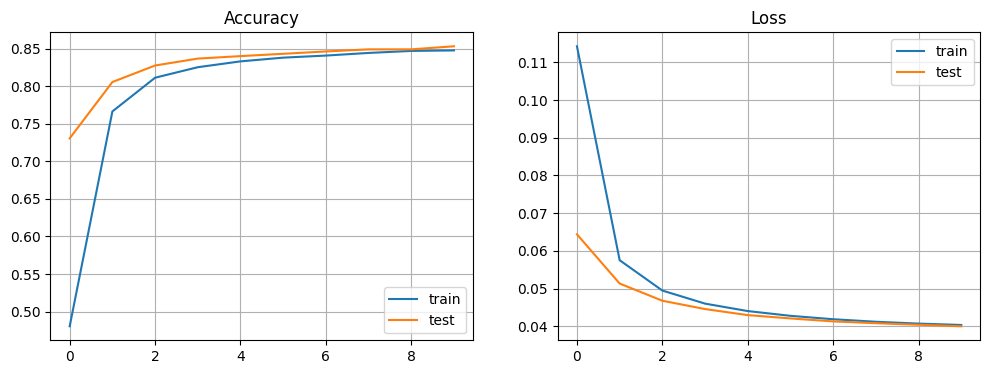

In [62]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 1000,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(X_test, y_test_oh), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)

pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test_oh)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test_oh)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test_oh,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test_oh,axis=1), pred_int))

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

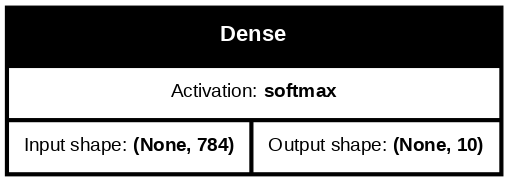

In [63]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/50
600/600 - 3s - 5ms/step - accuracy: 0.8991 - loss: 0.3573 - val_accuracy: 0.9109 - val_loss: 0.3032
Epoch 2/50
600/600 - 2s - 3ms/step - accuracy: 0.9166 - loss: 0.2974 - val_accuracy: 0.9188 - val_loss: 0.2867
Epoch 3/50
600/600 - 2s - 3ms/step - accuracy: 0.9213 - loss: 0.2869 - val_accuracy: 0.9221 - val_loss: 0.2917
Epoch 4/50
600/600 - 2s - 4ms/step - accuracy: 0.9219 - loss: 0.2850 - val_accuracy: 0.9198 - val_loss: 0.2860
Epoch 5/50
600/600 - 2s - 3ms/step - accuracy: 0.9240 - loss: 0.2818 - val_accuracy: 0.9205 - val_loss: 0.2980
Epoch 6/50
600/600 - 2s - 3ms/step - accuracy: 0.9232 - loss: 0.2755 - val_accuracy: 0.9244 - val_loss: 0.2984
Epoch 7/50
600/600 - 2s - 3ms/step - accuracy: 0.9238 - loss: 0.2756 - val_accuracy: 0.9243 - val_loss: 0.2947
Epoch 8/50
600/600 - 2s - 3ms/step - accuracy: 0.9242 - loss: 0.2748 - val_accuracy: 0.9233 - val_loss: 0.3014
Epoch 9/50
600/600 - 2s - 3ms/step - accuracy: 0.9255 - loss: 0.2700 - val_accuracy: 0.9206 - val_loss: 0.3013
E

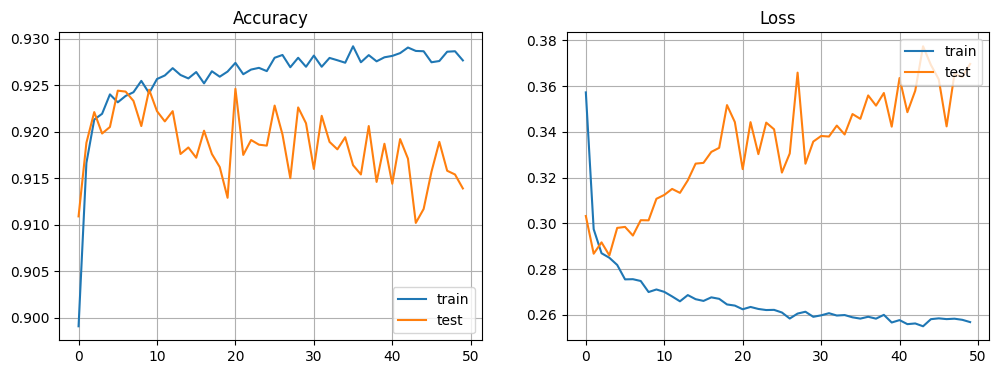

In [64]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 50, batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test_oh)
    )
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
plot_results(history)

y_pred = np.argmax(model.predict(X_test),axis=1)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,np.argmax(y_test_oh, axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test_oh,axis=1), y_pred))

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

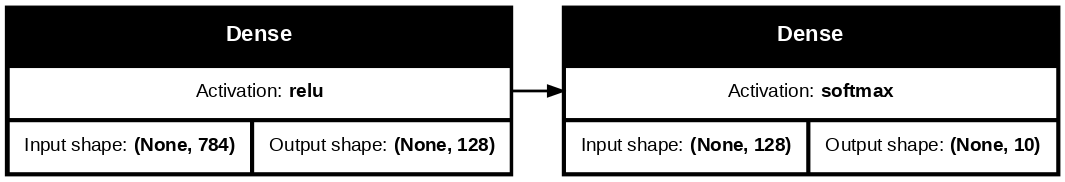

In [65]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(128,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

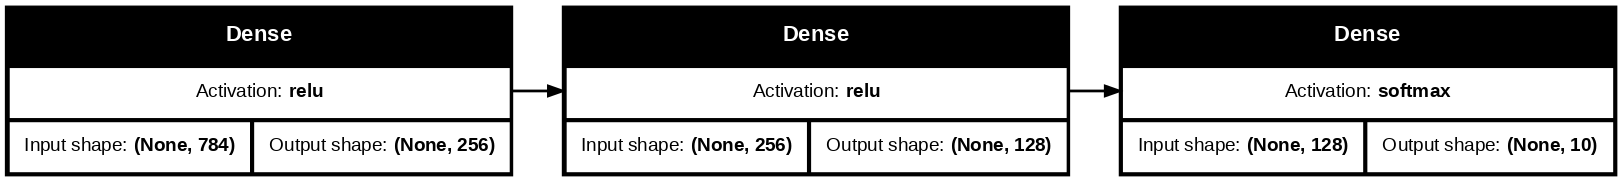

In [66]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(256,activation='relu'))
  model.add(Dense(128,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

model = logistic_regression(X_train.shape[1], 10)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

## Multilayer Dense Architecture Experiments

A controlled sequence compares one linear layer, one sigmoid layer, two linear layers, two sigmoid layers, sigmoid-softmax combinations, and additional feed-forward configurations.

We will experiment to see if adding linear and/or nonlinear layers improves the networks performance.

In [67]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

X_train = X_train.reshape(X_train.shape[0],-1)/255
X_test = X_test.reshape(X_test.shape[0],-1)/255

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Convert y to one-hot
print(y_train[:10])
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_train[:10])

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(60000, 784)
(60000,)
(10000, 784)
(10000,)
[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


## **One linear layer**

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

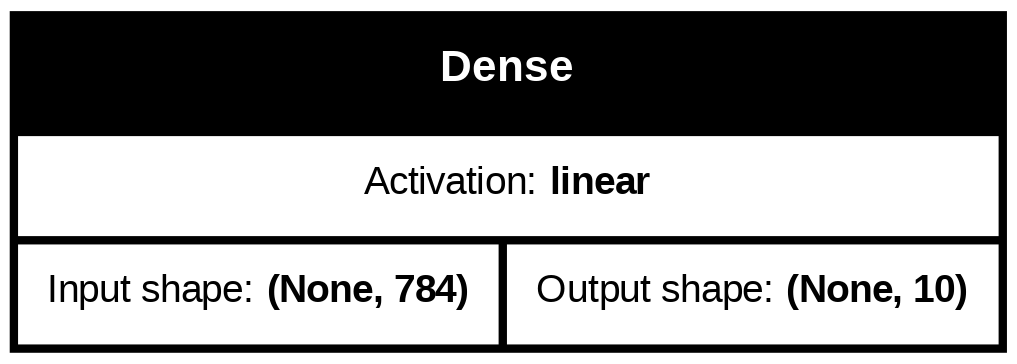

In [68]:
def linear_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10)])
  return model

model = linear_regression()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/10
60/60 - 2s - 33ms/step - accuracy: 0.4997 - loss: 0.1087 - val_accuracy: 0.7361 - val_loss: 0.0648
Epoch 2/10
60/60 - 0s - 5ms/step - accuracy: 0.7676 - loss: 0.0580 - val_accuracy: 0.8039 - val_loss: 0.0516
Epoch 3/10
60/60 - 0s - 5ms/step - accuracy: 0.8089 - loss: 0.0498 - val_accuracy: 0.8254 - val_loss: 0.0470
Epoch 4/10
60/60 - 0s - 5ms/step - accuracy: 0.8247 - loss: 0.0461 - val_accuracy: 0.8431 - val_loss: 0.0444
Epoch 5/10
60/60 - 0s - 5ms/step - accuracy: 0.8340 - loss: 0.0441 - val_accuracy: 0.8439 - val_loss: 0.0430
Epoch 6/10
60/60 - 0s - 6ms/step - accuracy: 0.8378 - loss: 0.0428 - val_accuracy: 0.8458 - val_loss: 0.0420
Epoch 7/10
60/60 - 0s - 6ms/step - accuracy: 0.8419 - loss: 0.0419 - val_accuracy: 0.8500 - val_loss: 0.0413
Epoch 8/10
60/60 - 0s - 5ms/step - accuracy: 0.8433 - loss: 0.0413 - val_accuracy: 0.8508 - val_loss: 0.0409
Epoch 9/10
60/60 - 0s - 5ms/step - accuracy: 0.8459 - loss: 0.0408 - val_accuracy: 0.8493 - val_loss: 0.0404
Epoch 10/10
60/60 

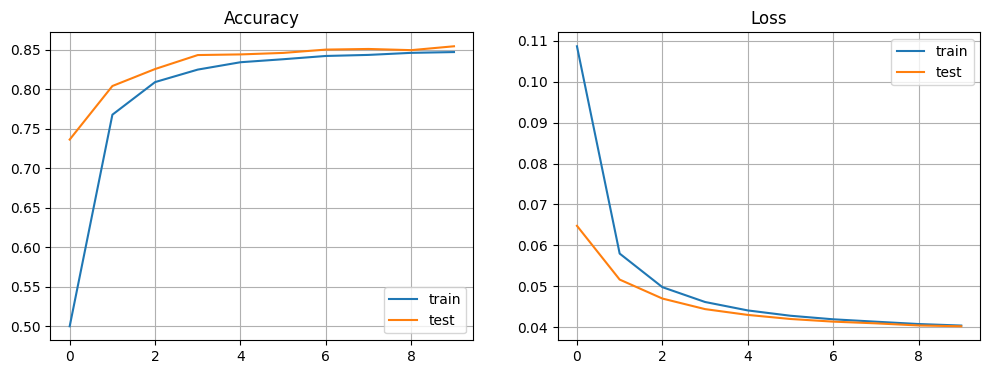

In [69]:
start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 10,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **One sigmoid layer**

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

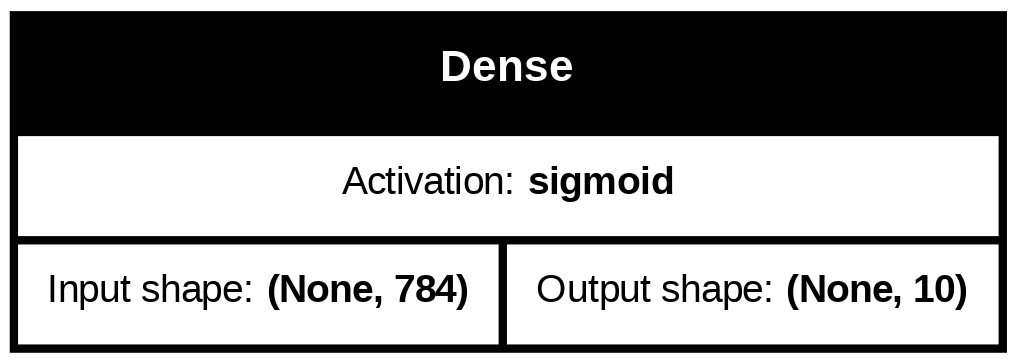

In [70]:
def logistic_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10,  activation='sigmoid')])
  return model

model = logistic_regression()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
60/60 - 1s - 25ms/step - accuracy: 0.2108 - loss: 0.1159 - val_accuracy: 0.4195 - val_loss: 0.0824
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.5486 - loss: 0.0722 - val_accuracy: 0.6632 - val_loss: 0.0619
Epoch 3/40
60/60 - 0s - 6ms/step - accuracy: 0.7033 - loss: 0.0561 - val_accuracy: 0.7433 - val_loss: 0.0501
Epoch 4/40
60/60 - 0s - 5ms/step - accuracy: 0.7533 - loss: 0.0473 - val_accuracy: 0.7842 - val_loss: 0.0433
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.8108 - loss: 0.0413 - val_accuracy: 0.8453 - val_loss: 0.0379
Epoch 6/40
60/60 - 1s - 10ms/step - accuracy: 0.8454 - loss: 0.0366 - val_accuracy: 0.8584 - val_loss: 0.0341
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.8553 - loss: 0.0334 - val_accuracy: 0.8662 - val_loss: 0.0315
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.8633 - loss: 0.0312 - val_accuracy: 0.8727 - val_loss: 0.0295
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.8687 - loss: 0.0294 - val_accuracy: 0.8781 - val_loss: 0.0280
Epoch 10/40
60/60

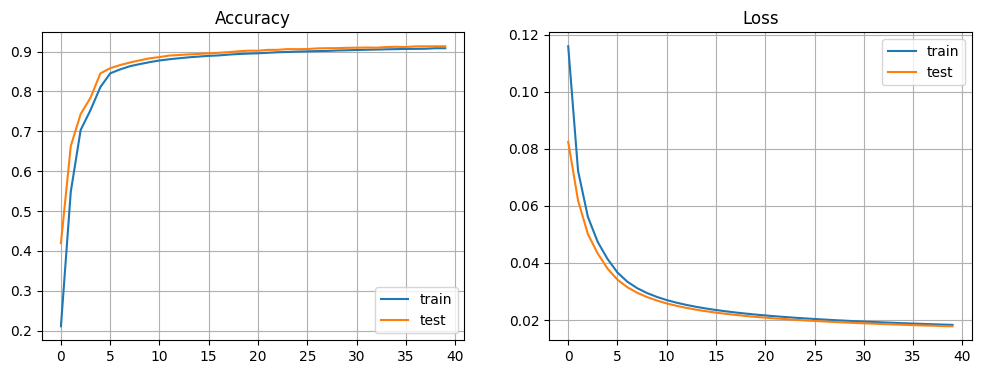

In [71]:
start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

In [72]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap='gray')

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% (True class: {})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  #plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

y_test_int = np.argmax(y_test,axis=1)
pred_int = np.argmax(pred,axis=1)

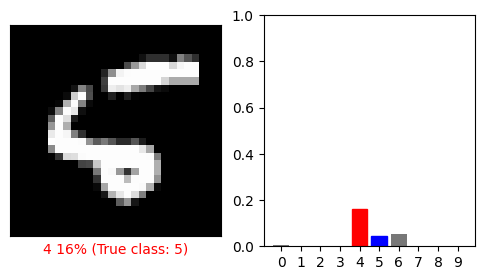

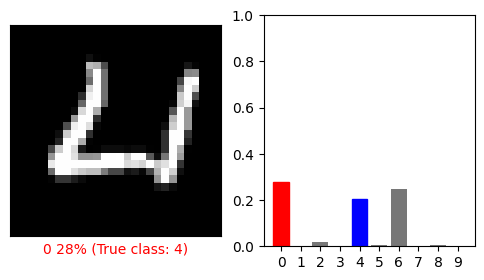

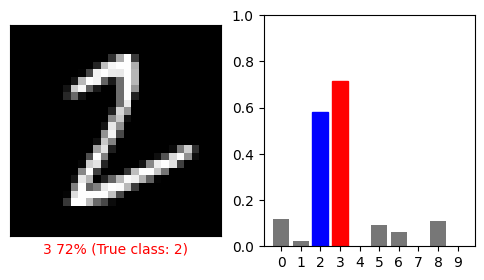

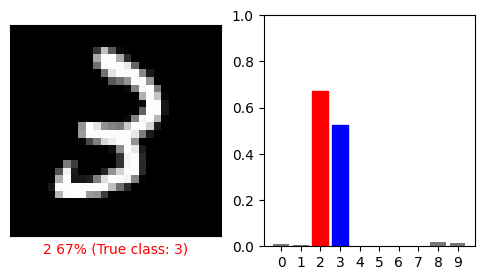

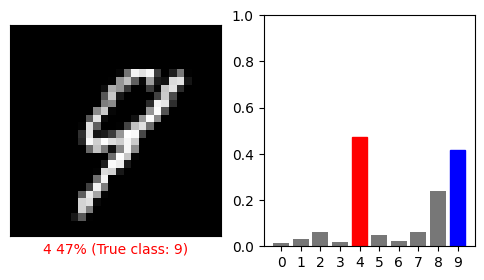

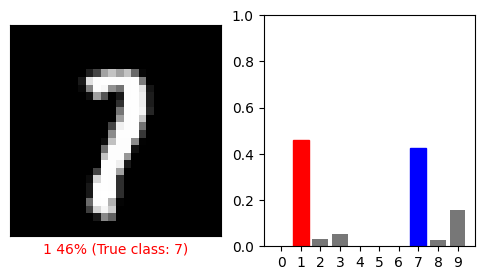

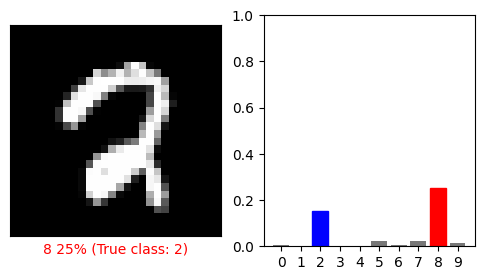

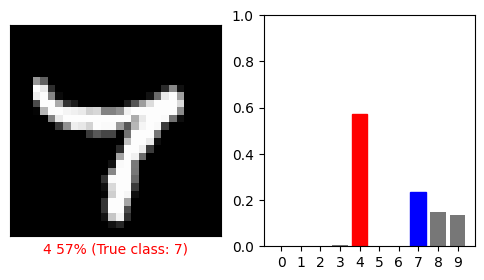

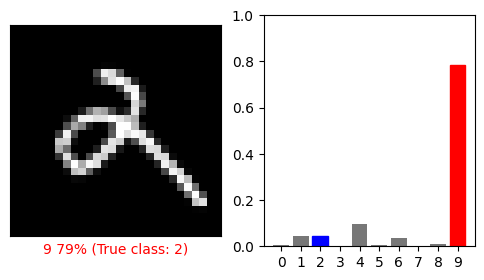

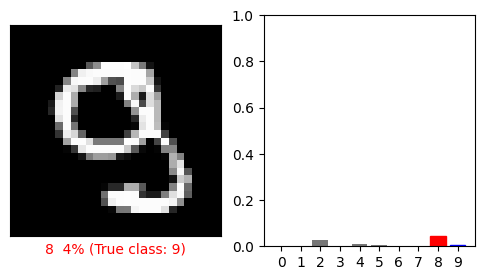

In [73]:
i, count = 0, 0
while count<10:
  if pred_int[i]!= y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

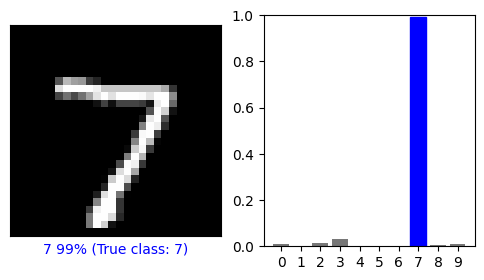

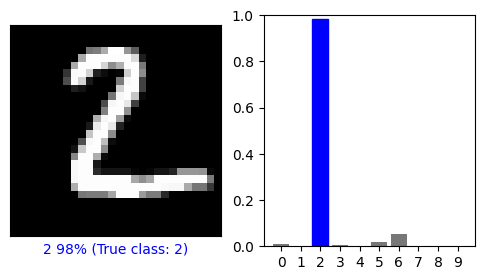

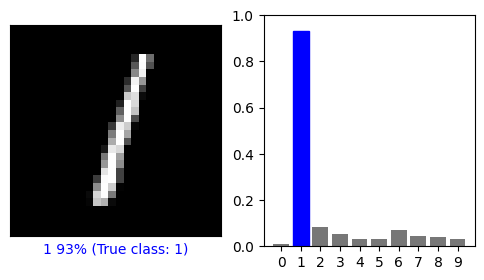

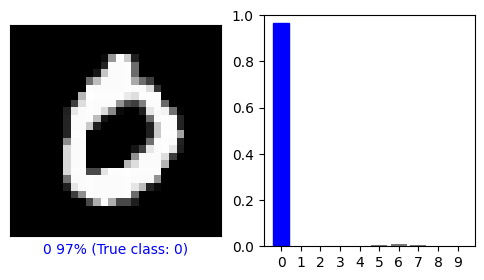

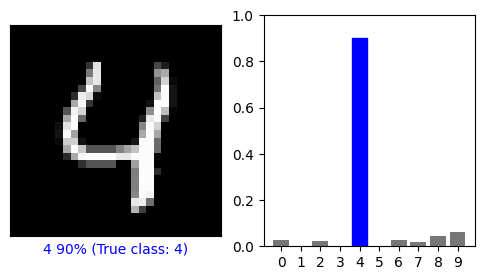

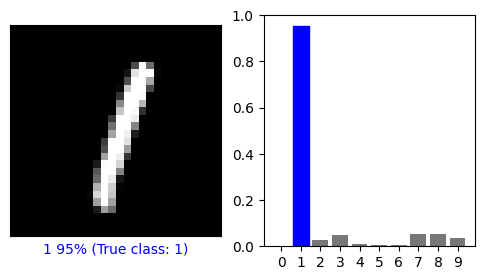

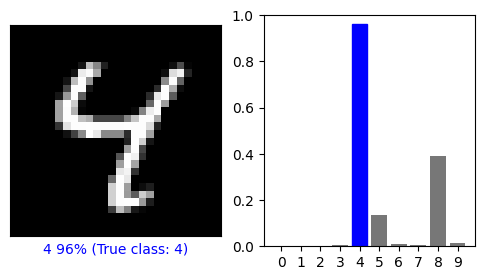

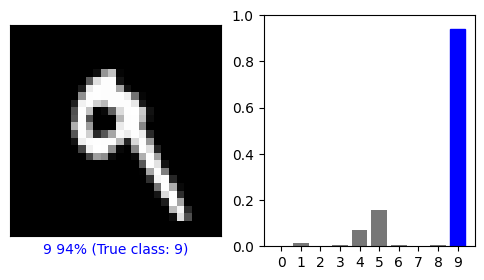

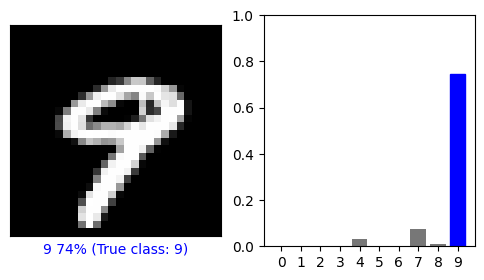

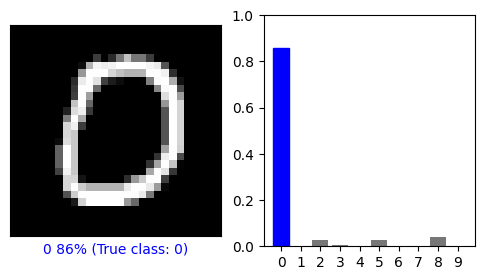

In [74]:
i, count = 0, 0
while count<10:
  if pred_int[i]== y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 2s - 26ms/step - accuracy: 0.6346 - loss: 0.0599 - val_accuracy: 0.8178 - val_loss: 0.0356
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.8461 - loss: 0.0294 - val_accuracy: 0.8741 - val_loss: 0.0236
Epoch 3/40
60/60 - 0s - 5ms/step - accuracy: 0.8757 - loss: 0.0224 - val_accuracy: 0.8914 - val_loss: 0.0197
Epoch 4/40
60/60 - 0s - 5ms/step - accuracy: 0.8896 - loss: 0.0194 - val_accuracy: 0.9005 - val_loss: 0.0176
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.8974 - loss: 0.0177 - val_accuracy: 0.9066 - val_loss: 0.0163
Epoch 6/40
60/60 - 0s - 5ms/step - accuracy: 0.9025 - loss: 0.0165 - val_accuracy: 0.9104 - val_loss: 0.0153
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.9063 - loss: 0.0157 - val_accuracy: 0.9120 - val_loss: 0.0147
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.9099 - loss: 0.0150 - val_accuracy: 0.9148 - val_loss: 0.0142
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.9123 - loss: 0.0145 - val_accuracy: 0.9178 - val_loss: 0.0137
Epoch 10/40
60/60 

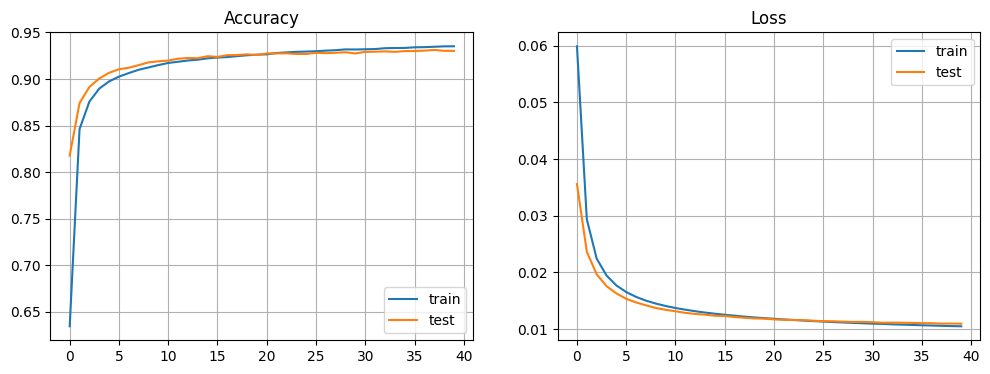

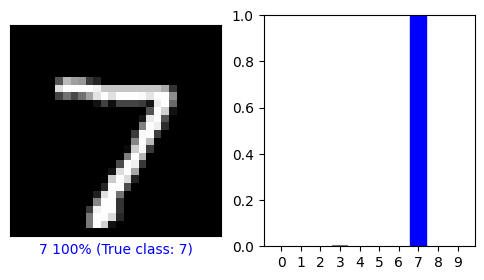

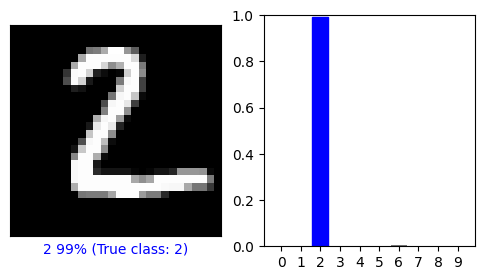

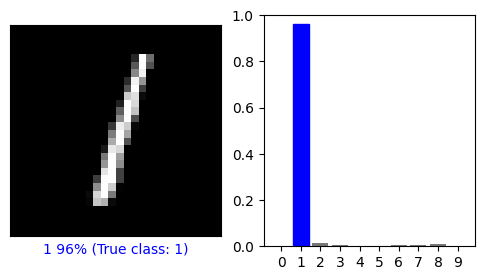

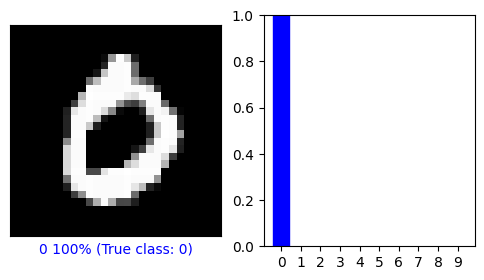

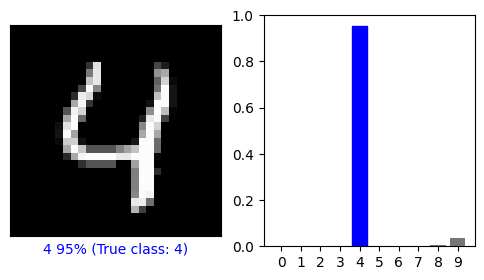

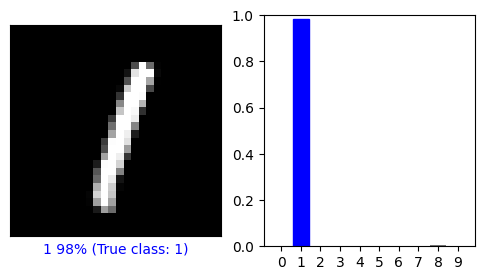

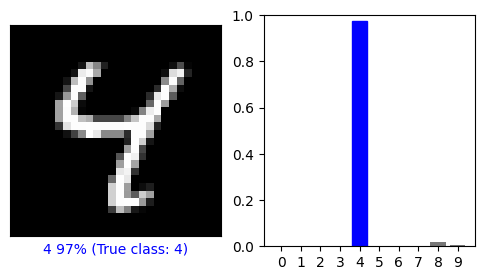

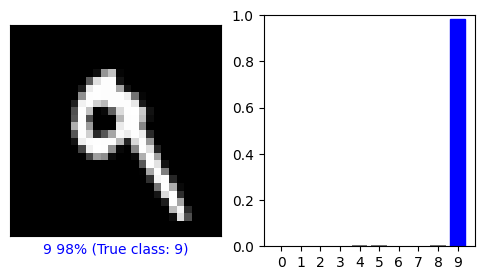

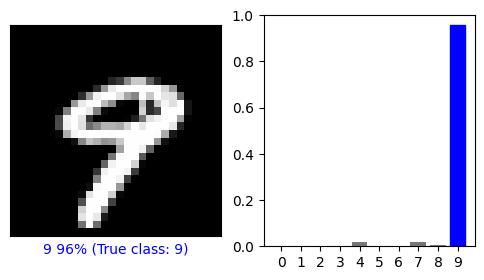

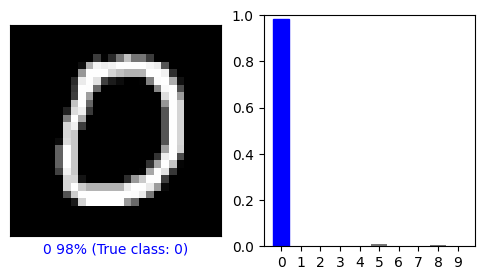

In [75]:
def logistic_regression():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = logistic_regression()
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.1,momentum=0.9)
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])

plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

y_test_int = np.argmax(y_test,axis=1)
pred_int = np.argmax(pred,axis=1)

i, count = 0, 0
while count<10:
  if pred_int[i]== y_test_int[i]:
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, pred[i], y_test_int, X_test.reshape(-1,28,28))
    plt.subplot(1,2,2)
    plot_value_array(i, pred[i],  y_test_int)
    plt.show()
    count +=1
  i += 1

## **Two linear layers**

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 2s - 37ms/step - accuracy: 0.6649 - loss: 0.0871 - val_accuracy: 0.8262 - val_loss: 0.0467
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.8305 - loss: 0.0444 - val_accuracy: 0.8457 - val_loss: 0.0420
Epoch 3/40
60/60 - 0s - 5ms/step - accuracy: 0.8432 - loss: 0.0416 - val_accuracy: 0.8537 - val_loss: 0.0404
Epoch 4/40
60/60 - 1s - 10ms/step - accuracy: 0.8474 - loss: 0.0404 - val_accuracy: 0.8543 - val_loss: 0.0397
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.8493 - loss: 0.0399 - val_accuracy: 0.8569 - val_loss: 0.0394
Epoch 6/40
60/60 - 0s - 5ms/step - accuracy: 0.8508 - loss: 0.0395 - val_accuracy: 0.8568 - val_loss: 0.0391
Epoch 7/40
60/60 - 0s - 8ms/step - accuracy: 0.8512 - loss: 0.0393 - val_accuracy: 0.8594 - val_loss: 0.0390
Epoch 8/40
60/60 - 1s - 10ms/step - accuracy: 0.8516 - loss: 0.0391 - val_accuracy: 0.8549 - val_loss: 0.0390
Epoch 9/40
60/60 - 0s - 7ms/step - accuracy: 0.8530 - loss: 0.0391 - val_accuracy: 0.8595 - val_loss: 0.0387
Epoch 10/40
60/6

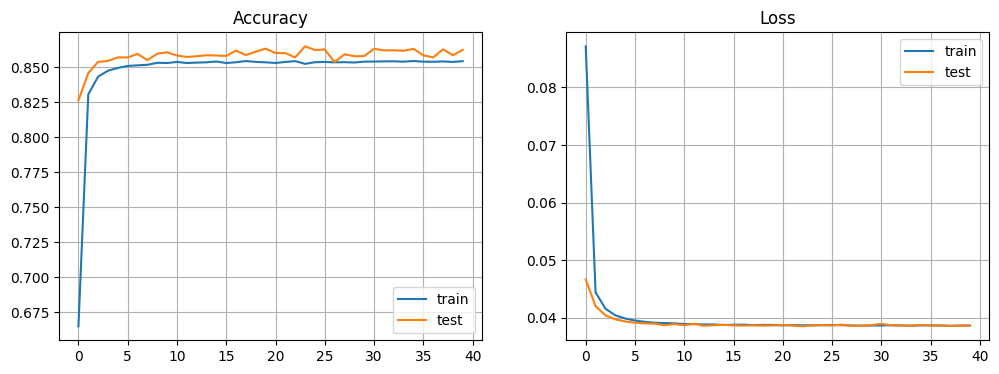

In [76]:
def linear_two():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10)])
  return model

model = linear_two()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **Two sigmoid layers**

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 2s - 30ms/step - accuracy: 0.4950 - loss: 0.0951 - val_accuracy: 0.6508 - val_loss: 0.0700
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.7314 - loss: 0.0595 - val_accuracy: 0.8136 - val_loss: 0.0498
Epoch 3/40
60/60 - 0s - 5ms/step - accuracy: 0.8243 - loss: 0.0446 - val_accuracy: 0.8542 - val_loss: 0.0389
Epoch 4/40
60/60 - 0s - 5ms/step - accuracy: 0.8557 - loss: 0.0362 - val_accuracy: 0.8763 - val_loss: 0.0325
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.8724 - loss: 0.0310 - val_accuracy: 0.8862 - val_loss: 0.0283
Epoch 6/40
60/60 - 0s - 5ms/step - accuracy: 0.8826 - loss: 0.0274 - val_accuracy: 0.8926 - val_loss: 0.0253
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.8903 - loss: 0.0249 - val_accuracy: 0.8987 - val_loss: 0.0231
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.8954 - loss: 0.0229 - val_accuracy: 0.9034 - val_loss: 0.0214
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.9001 - loss: 0.0213 - val_accuracy: 0.9068 - val_loss: 0.0200
Epoch 10/40
60/60 

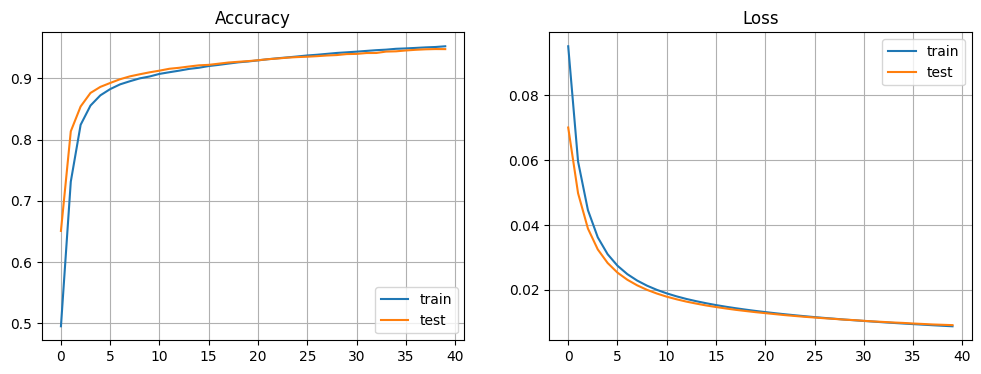

In [77]:
def sigmoid_two():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100,  activation='sigmoid'),
    tf.keras.layers.Dense(10,  activation='sigmoid')])
  return model

model = sigmoid_two()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## **One sigmoid layer and one softmax layer**

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 2s - 30ms/step - accuracy: 0.6072 - loss: 0.0627 - val_accuracy: 0.8171 - val_loss: 0.0365
Epoch 2/40
60/60 - 0s - 5ms/step - accuracy: 0.8584 - loss: 0.0277 - val_accuracy: 0.8933 - val_loss: 0.0208
Epoch 3/40
60/60 - 0s - 5ms/step - accuracy: 0.8942 - loss: 0.0190 - val_accuracy: 0.9079 - val_loss: 0.0163
Epoch 4/40
60/60 - 0s - 5ms/step - accuracy: 0.9074 - loss: 0.0158 - val_accuracy: 0.9153 - val_loss: 0.0142
Epoch 5/40
60/60 - 0s - 5ms/step - accuracy: 0.9161 - loss: 0.0140 - val_accuracy: 0.9211 - val_loss: 0.0129
Epoch 6/40
60/60 - 0s - 5ms/step - accuracy: 0.9219 - loss: 0.0129 - val_accuracy: 0.9254 - val_loss: 0.0120
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.9274 - loss: 0.0119 - val_accuracy: 0.9308 - val_loss: 0.0113
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.9319 - loss: 0.0112 - val_accuracy: 0.9327 - val_loss: 0.0108
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.9351 - loss: 0.0106 - val_accuracy: 0.9365 - val_loss: 0.0103
Epoch 10/40
60/60 

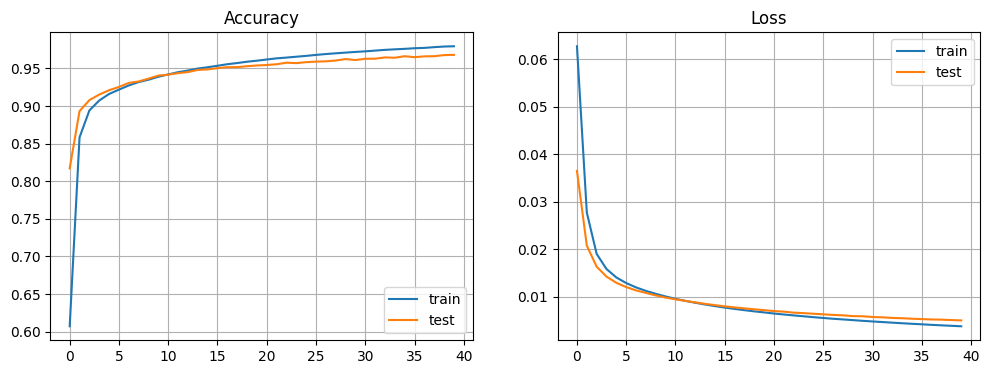

In [78]:
def sigmoid_softmax():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(100,  activation='sigmoid'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = sigmoid_softmax()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 800)            │       640,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,810 (4.87 MB)

 Trainable params: 1,276,810 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 3s - 50ms/step - accuracy: 0.8907 - loss: 0.3975 - val_accuracy: 0.9515 - val_loss: 0.1654
Epoch 2/40
60/60 - 0s - 6ms/step - accuracy: 0.9622 - loss: 0.1291 - val_accuracy: 0.9640 - val_loss: 0.1135
Epoch 3/40
60/60 - 0s - 6ms/step - accuracy: 0.9762 - loss: 0.0815 - val_accuracy: 0.9714 - val_loss: 0.0925
Epoch 4/40
60/60 - 0s - 6ms/step - accuracy: 0.9839 - loss: 0.0552 - val_accuracy: 0.9760 - val_loss: 0.0749
Epoch 5/40
60/60 - 1s - 11ms/step - accuracy: 0.9876 - loss: 0.0417 - val_accuracy: 0.9765 - val_loss: 0.0743
Epoch 6/40
60/60 - 0s - 6ms/step - accuracy: 0.9918 - loss: 0.0292 - val_accuracy: 0.9782 - val_loss: 0.0678
Epoch 7/40
60/60 - 0s - 6ms/step - accuracy: 0.9946 - loss: 0.0202 - val_accuracy: 0.9801 - val_loss: 0.0671
Epoch 8/40
60/60 - 0s - 7ms/step - accuracy: 0.9967 - loss: 0.0140 - val_accuracy: 0.9811 - val_loss: 0.0617
Epoch 9/40
60/60 - 0s - 6ms/step - accuracy: 0.9978 - loss: 0.0103 - val_accuracy: 0.9809 - val_loss: 0.0633
Epoch 10/40
60/60

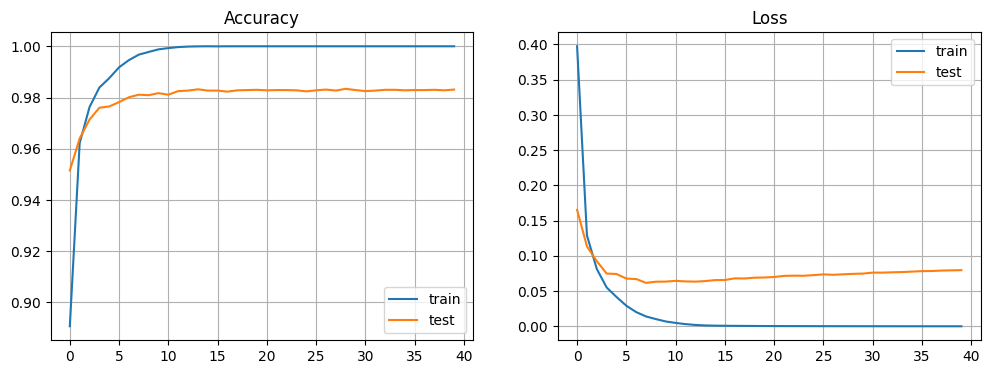

In [79]:
def ffnn():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = ffnn()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
60/60 - 3s - 46ms/step - accuracy: 0.7997 - loss: 0.7521 - val_accuracy: 0.9191 - val_loss: 0.2786
Epoch 2/40
60/60 - 0s - 8ms/step - accuracy: 0.9316 - loss: 0.2416 - val_accuracy: 0.9421 - val_loss: 0.1989
Epoch 3/40
60/60 - 1s - 8ms/step - accuracy: 0.9491 - loss: 0.1793 - val_accuracy: 0.9520 - val_loss: 0.1594
Epoch 4/40
60/60 - 1s - 11ms/step - accuracy: 0.9581 - loss: 0.1449 - val_accuracy: 0.9601 - val_loss: 0.1347
Epoch 5/40
60/60 - 0s - 8ms/step - accuracy: 0.9658 - loss: 0.1183 - val_accuracy: 0.9663 - val_loss: 0.1191
Epoch 6/40
60/60 - 0s - 6ms/step - accuracy: 0.9706 - loss: 0.1015 - val_accuracy: 0.9695 - val_loss: 0.1053
Epoch 7/40
60/60 - 0s - 5ms/step - accuracy: 0.9744 - loss: 0.0880 - val_accuracy: 0.9695 - val_loss: 0.0982
Epoch 8/40
60/60 - 0s - 5ms/step - accuracy: 0.9776 - loss: 0.0781 - val_accuracy: 0.9712 - val_loss: 0.0926
Epoch 9/40
60/60 - 0s - 5ms/step - accuracy: 0.9797 - loss: 0.0703 - val_accuracy: 0.9733 - val_loss: 0.0863
Epoch 10/40
60/60

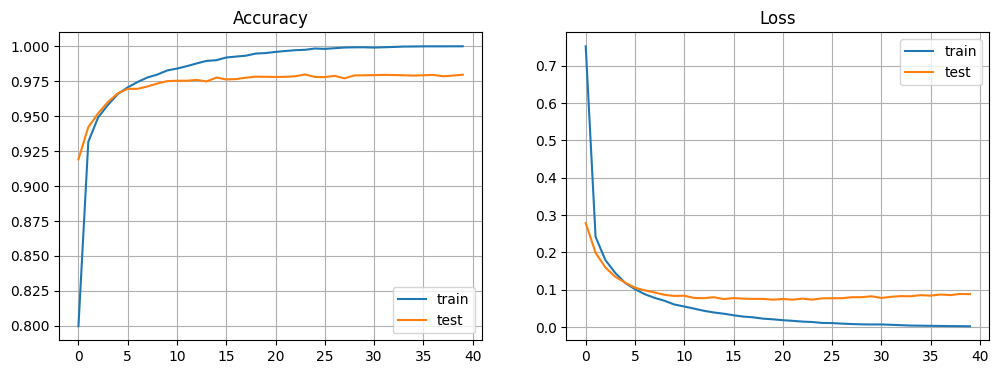

In [80]:
def ffnn():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128,  activation='relu'),
    tf.keras.layers.Dense(128,  activation='relu'),
    #tf.keras.layers.Dense(800,  activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')])
  return model

model = ffnn()
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs = 40,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))

## Hyperparameter and Feature-Order Experiments

The one-hidden-layer network is evaluated across multiple epoch, batch-size, and learning-rate settings, followed by a fixed column-shuffling experiment.

In [81]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


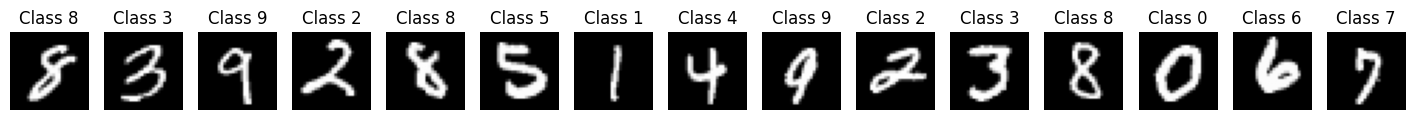

In [82]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

nimgs = 15
sel = np.random.randint(0,X_train.shape[0],size =nimgs)
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s].reshape(28,28),cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

## Hyperparameter Sensitivity

Evaluate the performance of the network with one hidden layer on the MNIST dataset when you modify.

*   Number of epochs
*   Batch size
*   Learning rate

For each experiment, write a paragraph describing your results.

In [83]:
def ffnn_one_HL(n_inputs, hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
240/240 - 3s - 11ms/step - accuracy: 0.9316 - loss: 0.2311 - val_accuracy: 0.9642 - val_loss: 0.1122
Epoch 2/10
240/240 - 1s - 3ms/step - accuracy: 0.9716 - loss: 0.0925 - val_accuracy: 0.9712 - val_loss: 0.0927
Epoch 3/10
240/240 - 1s - 3ms/step - accuracy: 0.9780 - loss: 0.0676 - val_accuracy: 0.9714 - val_loss: 0.0982
Epoch 4/10
240/240 - 1s - 4ms/step - accuracy: 0.9818 - loss: 0.0568 - val_accuracy: 0.9715 - val_loss: 0.1118
Epoch 5/10
240/240 - 1s - 5ms/step - accuracy: 0.9833 - loss: 0.0544 - val_accuracy: 0.9744 - val_loss: 0.1103
Epoch 6/10
240/240 - 1s - 5ms/step - accuracy: 0.9853 - loss: 0.0480 - val_accuracy: 0.9706 - val_loss: 0.1187
Epoch 7/10
240/240 - 1s - 3ms/step - accuracy: 0.9866 - loss: 0.0445 - val_accuracy: 0.9753 - val_loss: 0.1138
Epoch 8/10
240/240 - 1s - 3ms/step - accuracy: 0.9894 - loss: 0.0362 - val_accuracy: 0.9708 - val_loss: 0.1342
Epoch 9/10
240/240 - 1s - 3ms/step - accuracy: 0.9874 - loss: 0.0449 - val_accuracy: 0.9767 - val_loss: 0.1246


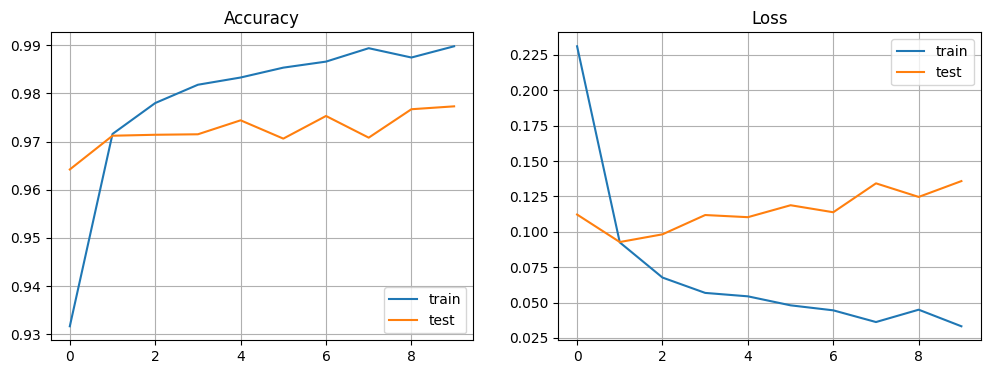

In [84]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
240/240 - 2s - 9ms/step - accuracy: 0.9106 - loss: 0.3234 - val_accuracy: 0.9555 - val_loss: 0.1622
Epoch 2/10
240/240 - 1s - 3ms/step - accuracy: 0.9617 - loss: 0.1348 - val_accuracy: 0.9654 - val_loss: 0.1167
Epoch 3/10
240/240 - 1s - 3ms/step - accuracy: 0.9732 - loss: 0.0921 - val_accuracy: 0.9741 - val_loss: 0.0880
Epoch 4/10
240/240 - 1s - 3ms/step - accuracy: 0.9809 - loss: 0.0676 - val_accuracy: 0.9753 - val_loss: 0.0833
Epoch 5/10
240/240 - 1s - 4ms/step - accuracy: 0.9842 - loss: 0.0517 - val_accuracy: 0.9791 - val_loss: 0.0686
Epoch 6/10
240/240 - 1s - 5ms/step - accuracy: 0.9884 - loss: 0.0405 - val_accuracy: 0.9774 - val_loss: 0.0720
Epoch 7/10
240/240 - 1s - 4ms/step - accuracy: 0.9915 - loss: 0.0311 - val_accuracy: 0.9793 - val_loss: 0.0647
Epoch 8/10
240/240 - 1s - 3ms/step - accuracy: 0.9940 - loss: 0.0252 - val_accuracy: 0.9804 - val_loss: 0.0637
Epoch 9/10
240/240 - 1s - 3ms/step - accuracy: 0.9952 - loss: 0.0195 - val_accuracy: 0.9786 - val_loss: 0.0637
E

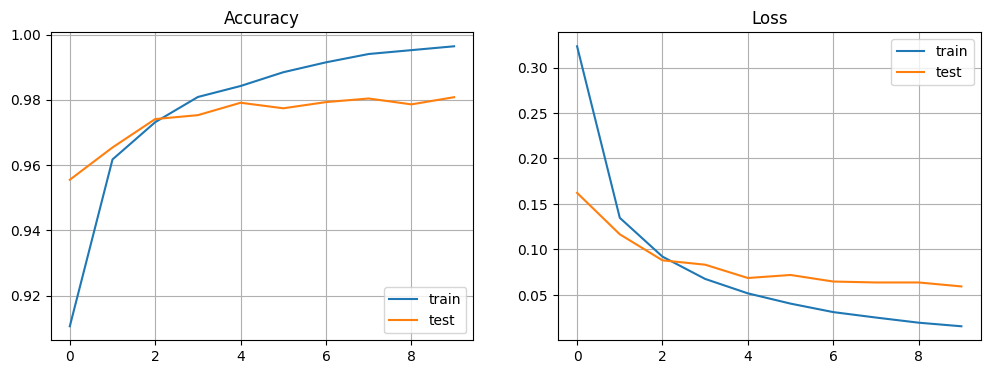

In [85]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
120/120 - 2s - 17ms/step - accuracy: 0.9196 - loss: 0.2601 - val_accuracy: 0.9648 - val_loss: 0.1109
Epoch 2/10
120/120 - 0s - 4ms/step - accuracy: 0.9740 - loss: 0.0853 - val_accuracy: 0.9772 - val_loss: 0.0747
Epoch 3/10
120/120 - 0s - 4ms/step - accuracy: 0.9823 - loss: 0.0550 - val_accuracy: 0.9697 - val_loss: 0.0944
Epoch 4/10
120/120 - 0s - 4ms/step - accuracy: 0.9861 - loss: 0.0422 - val_accuracy: 0.9749 - val_loss: 0.0848
Epoch 5/10
120/120 - 1s - 4ms/step - accuracy: 0.9887 - loss: 0.0346 - val_accuracy: 0.9789 - val_loss: 0.0741
Epoch 6/10
120/120 - 0s - 4ms/step - accuracy: 0.9909 - loss: 0.0274 - val_accuracy: 0.9806 - val_loss: 0.0715
Epoch 7/10
120/120 - 0s - 4ms/step - accuracy: 0.9911 - loss: 0.0254 - val_accuracy: 0.9756 - val_loss: 0.0957
Epoch 8/10
120/120 - 0s - 4ms/step - accuracy: 0.9903 - loss: 0.0282 - val_accuracy: 0.9776 - val_loss: 0.0916
Epoch 9/10
120/120 - 1s - 5ms/step - accuracy: 0.9921 - loss: 0.0241 - val_accuracy: 0.9751 - val_loss: 0.1056


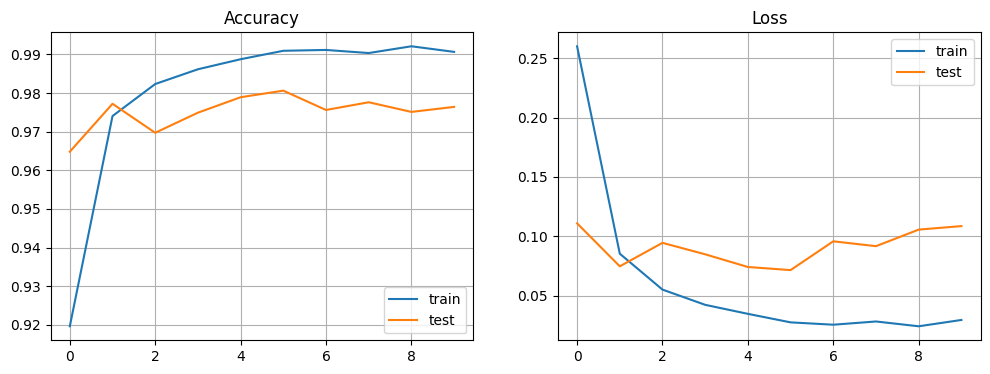

In [86]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
120/120 - 2s - 17ms/step - accuracy: 0.8856 - loss: 0.4219 - val_accuracy: 0.9401 - val_loss: 0.2095
Epoch 2/10
120/120 - 0s - 4ms/step - accuracy: 0.9491 - loss: 0.1793 - val_accuracy: 0.9571 - val_loss: 0.1487
Epoch 3/10
120/120 - 0s - 4ms/step - accuracy: 0.9638 - loss: 0.1269 - val_accuracy: 0.9660 - val_loss: 0.1167
Epoch 4/10
120/120 - 0s - 4ms/step - accuracy: 0.9734 - loss: 0.0953 - val_accuracy: 0.9703 - val_loss: 0.1023
Epoch 5/10
120/120 - 0s - 4ms/step - accuracy: 0.9787 - loss: 0.0764 - val_accuracy: 0.9735 - val_loss: 0.0876
Epoch 6/10
120/120 - 0s - 4ms/step - accuracy: 0.9829 - loss: 0.0619 - val_accuracy: 0.9766 - val_loss: 0.0785
Epoch 7/10
120/120 - 0s - 4ms/step - accuracy: 0.9869 - loss: 0.0498 - val_accuracy: 0.9772 - val_loss: 0.0725
Epoch 8/10
120/120 - 0s - 4ms/step - accuracy: 0.9889 - loss: 0.0425 - val_accuracy: 0.9780 - val_loss: 0.0697
Epoch 9/10
120/120 - 0s - 4ms/step - accuracy: 0.9916 - loss: 0.0349 - val_accuracy: 0.9785 - val_loss: 0.0670


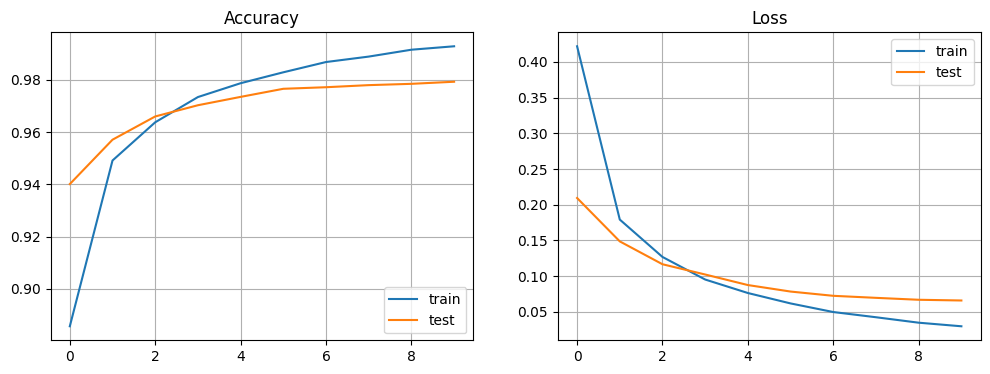

In [87]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 10,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
240/240 - 3s - 11ms/step - accuracy: 0.9340 - loss: 0.2122 - val_accuracy: 0.9661 - val_loss: 0.1095
Epoch 2/20
240/240 - 1s - 5ms/step - accuracy: 0.9719 - loss: 0.0901 - val_accuracy: 0.9705 - val_loss: 0.1020
Epoch 3/20
240/240 - 1s - 4ms/step - accuracy: 0.9773 - loss: 0.0707 - val_accuracy: 0.9762 - val_loss: 0.0838
Epoch 4/20
240/240 - 1s - 3ms/step - accuracy: 0.9822 - loss: 0.0565 - val_accuracy: 0.9732 - val_loss: 0.1026
Epoch 5/20
240/240 - 1s - 3ms/step - accuracy: 0.9841 - loss: 0.0510 - val_accuracy: 0.9717 - val_loss: 0.1154
Epoch 6/20
240/240 - 1s - 3ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9775 - val_loss: 0.0972
Epoch 7/20
240/240 - 1s - 3ms/step - accuracy: 0.9872 - loss: 0.0416 - val_accuracy: 0.9749 - val_loss: 0.1147
Epoch 8/20
240/240 - 1s - 3ms/step - accuracy: 0.9880 - loss: 0.0404 - val_accuracy: 0.9743 - val_loss: 0.1279
Epoch 9/20
240/240 - 1s - 3ms/step - accuracy: 0.9896 - loss: 0.0339 - val_accuracy: 0.9722 - val_loss: 0.1453


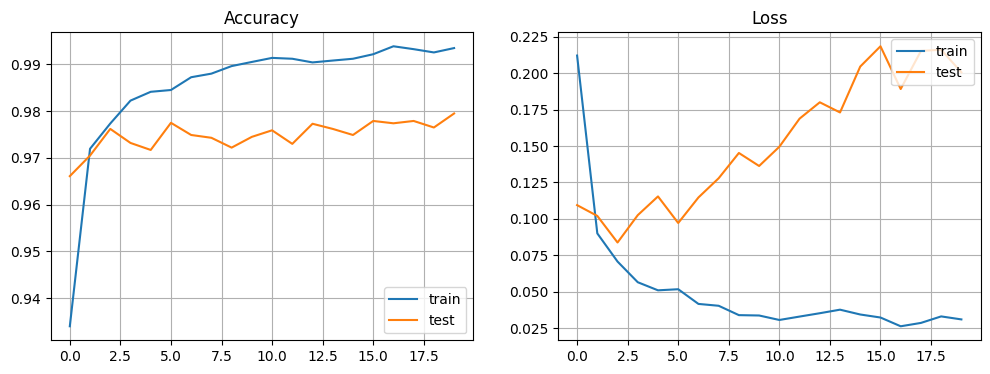

In [88]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
240/240 - 2s - 9ms/step - accuracy: 0.9094 - loss: 0.3285 - val_accuracy: 0.9523 - val_loss: 0.1706
Epoch 2/20
240/240 - 1s - 3ms/step - accuracy: 0.9620 - loss: 0.1363 - val_accuracy: 0.9668 - val_loss: 0.1107
Epoch 3/20
240/240 - 1s - 3ms/step - accuracy: 0.9732 - loss: 0.0928 - val_accuracy: 0.9726 - val_loss: 0.0902
Epoch 4/20
240/240 - 1s - 3ms/step - accuracy: 0.9812 - loss: 0.0675 - val_accuracy: 0.9749 - val_loss: 0.0798
Epoch 5/20
240/240 - 1s - 3ms/step - accuracy: 0.9857 - loss: 0.0519 - val_accuracy: 0.9791 - val_loss: 0.0714
Epoch 6/20
240/240 - 1s - 3ms/step - accuracy: 0.9889 - loss: 0.0401 - val_accuracy: 0.9796 - val_loss: 0.0663
Epoch 7/20
240/240 - 1s - 4ms/step - accuracy: 0.9916 - loss: 0.0317 - val_accuracy: 0.9791 - val_loss: 0.0667
Epoch 8/20
240/240 - 1s - 5ms/step - accuracy: 0.9935 - loss: 0.0251 - val_accuracy: 0.9803 - val_loss: 0.0620
Epoch 9/20
240/240 - 1s - 4ms/step - accuracy: 0.9951 - loss: 0.0199 - val_accuracy: 0.9797 - val_loss: 0.0624
E

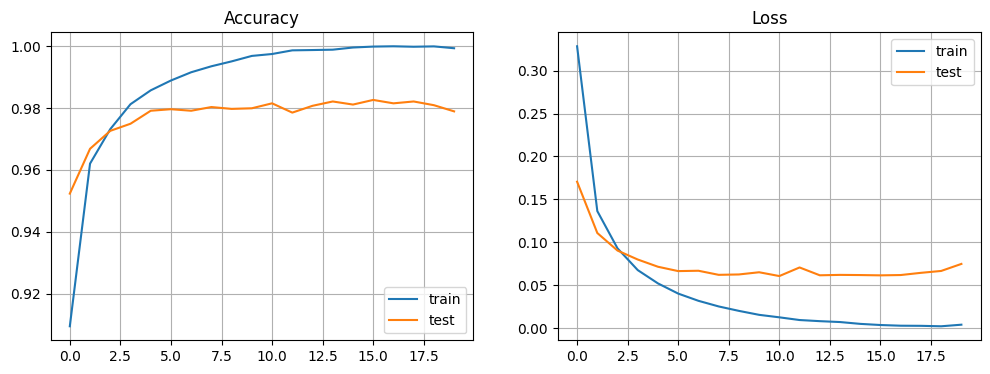

In [89]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 250,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 - 6s - 50ms/step - accuracy: 0.9102 - loss: 0.3064 - val_accuracy: 0.9636 - val_loss: 0.1156
Epoch 2/30
120/120 - 1s - 7ms/step - accuracy: 0.9715 - loss: 0.0929 - val_accuracy: 0.9721 - val_loss: 0.0849
Epoch 3/30
120/120 - 1s - 8ms/step - accuracy: 0.9801 - loss: 0.0614 - val_accuracy: 0.9696 - val_loss: 0.0907
Epoch 4/30
120/120 - 0s - 4ms/step - accuracy: 0.9869 - loss: 0.0411 - val_accuracy: 0.9694 - val_loss: 0.0938
Epoch 5/30
120/120 - 0s - 4ms/step - accuracy: 0.9895 - loss: 0.0323 - val_accuracy: 0.9769 - val_loss: 0.0750
Epoch 6/30
120/120 - 0s - 4ms/step - accuracy: 0.9911 - loss: 0.0263 - val_accuracy: 0.9798 - val_loss: 0.0791
Epoch 7/30
120/120 - 0s - 4ms/step - accuracy: 0.9916 - loss: 0.0248 - val_accuracy: 0.9758 - val_loss: 0.0962
Epoch 8/30
120/120 - 0s - 4ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9719 - val_loss: 0.1165
Epoch 9/30
120/120 - 0s - 4ms/step - accuracy: 0.9926 - loss: 0.0216 - val_accuracy: 0.9772 - val_loss: 0.0978


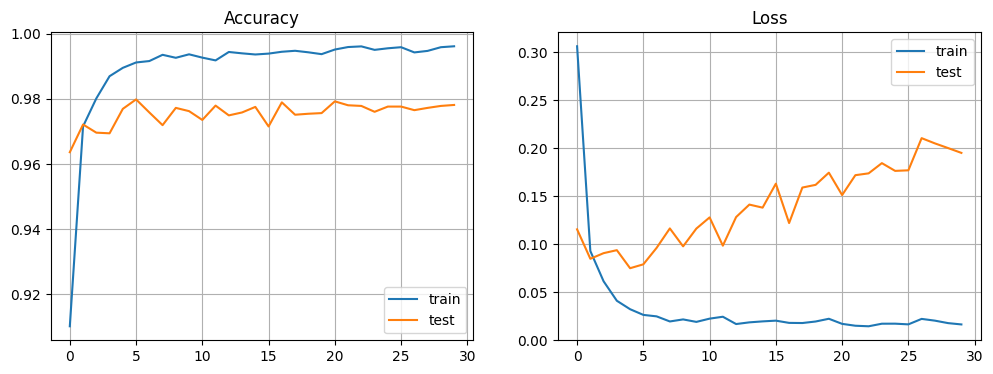

In [90]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 30,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 - 3s - 21ms/step - accuracy: 0.8888 - loss: 0.4095 - val_accuracy: 0.9400 - val_loss: 0.2116
Epoch 2/30
120/120 - 1s - 6ms/step - accuracy: 0.9504 - loss: 0.1756 - val_accuracy: 0.9567 - val_loss: 0.1478
Epoch 3/30
120/120 - 1s - 9ms/step - accuracy: 0.9657 - loss: 0.1226 - val_accuracy: 0.9665 - val_loss: 0.1149
Epoch 4/30
120/120 - 0s - 4ms/step - accuracy: 0.9732 - loss: 0.0954 - val_accuracy: 0.9699 - val_loss: 0.1005
Epoch 5/30
120/120 - 0s - 4ms/step - accuracy: 0.9793 - loss: 0.0748 - val_accuracy: 0.9749 - val_loss: 0.0842
Epoch 6/30
120/120 - 0s - 4ms/step - accuracy: 0.9836 - loss: 0.0603 - val_accuracy: 0.9771 - val_loss: 0.0759
Epoch 7/30
120/120 - 0s - 4ms/step - accuracy: 0.9865 - loss: 0.0500 - val_accuracy: 0.9772 - val_loss: 0.0740
Epoch 8/30
120/120 - 0s - 4ms/step - accuracy: 0.9885 - loss: 0.0422 - val_accuracy: 0.9788 - val_loss: 0.0675
Epoch 9/30
120/120 - 0s - 4ms/step - accuracy: 0.9913 - loss: 0.0348 - val_accuracy: 0.9789 - val_loss: 0.0678


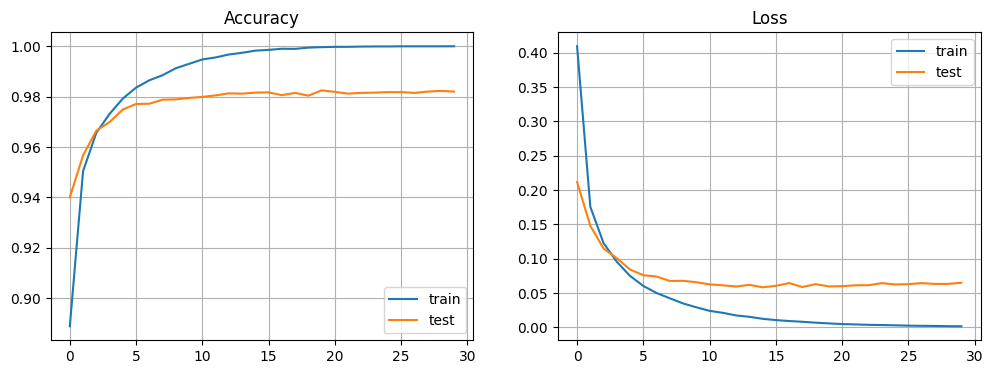

In [91]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 30,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

The one-hidden-layer FFNN performs best with moderate batch size (250) and a lower learning rate (0.001) trained for 10 epochs, achieving a balance between convergence speed, stability, and generalization.

## Feature-Order Sensitivity

Suppose we randomly shuffle the columns in the dataset. Does this make the problem more difficult for a person? Do you expect this will make the problem more difficult for a dense neural network?

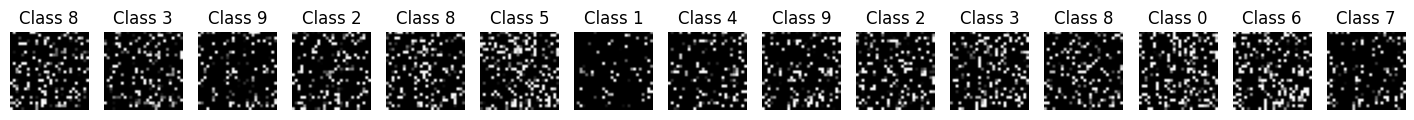

In [92]:
ind = np.random.permutation(X_train.shape[1])
X_train = X_train[:,ind]
X_test = X_test[:,ind]
fig, ax = plt.subplots(ncols=nimgs, figsize=(18,4))
for i, s in enumerate(sel):
  ax[i].imshow(X_train[s].reshape(28,28),cmap='gray')
  ax[i].set_title(f'Class {y_train[s]}')
  ax[i].set_axis_off()
plt.show()

Evaluate the performance of the neural network with one hidden layer on this modified dataset and compare it with the performance on the original dataset. Does the result match your expectations?

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
120/120 - 2s - 17ms/step - accuracy: 0.9224 - loss: 0.2503 - val_accuracy: 0.9692 - val_loss: 0.1011
Epoch 2/20
120/120 - 0s - 4ms/step - accuracy: 0.9733 - loss: 0.0878 - val_accuracy: 0.9733 - val_loss: 0.0919
Epoch 3/20
120/120 - 0s - 4ms/step - accuracy: 0.9829 - loss: 0.0554 - val_accuracy: 0.9744 - val_loss: 0.0855
Epoch 4/20
120/120 - 0s - 4ms/step - accuracy: 0.9867 - loss: 0.0417 - val_accuracy: 0.9776 - val_loss: 0.0780
Epoch 5/20
120/120 - 0s - 4ms/step - accuracy: 0.9882 - loss: 0.0360 - val_accuracy: 0.9743 - val_loss: 0.0866
Epoch 6/20
120/120 - 1s - 5ms/step - accuracy: 0.9912 - loss: 0.0264 - val_accuracy: 0.9790 - val_loss: 0.0832
Epoch 7/20
120/120 - 0s - 4ms/step - accuracy: 0.9923 - loss: 0.0215 - val_accuracy: 0.9788 - val_loss: 0.0841
Epoch 8/20
120/120 - 1s - 5ms/step - accuracy: 0.9906 - loss: 0.0271 - val_accuracy: 0.9764 - val_loss: 0.1176
Epoch 9/20
120/120 - 1s - 11ms/step - accuracy: 0.9927 - loss: 0.0224 - val_accuracy: 0.9787 - val_loss: 0.0966

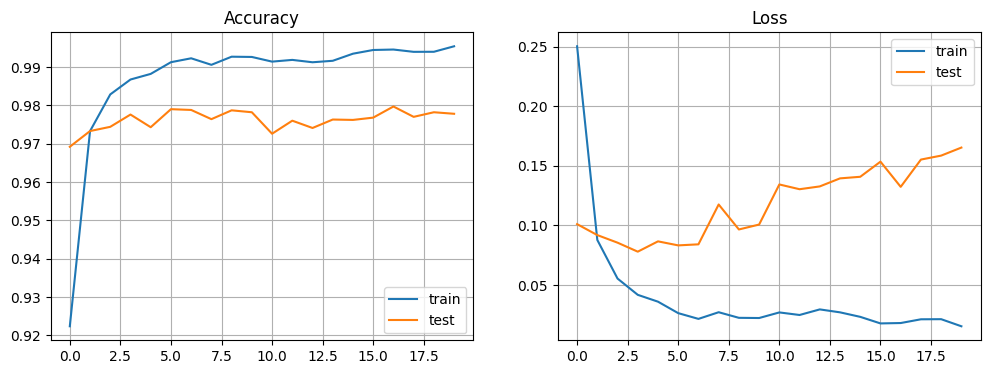

In [93]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
120/120 - 2s - 19ms/step - accuracy: 0.8892 - loss: 0.4069 - val_accuracy: 0.9394 - val_loss: 0.2144
Epoch 2/20
120/120 - 1s - 6ms/step - accuracy: 0.9496 - loss: 0.1795 - val_accuracy: 0.9579 - val_loss: 0.1480
Epoch 3/20
120/120 - 1s - 6ms/step - accuracy: 0.9638 - loss: 0.1292 - val_accuracy: 0.9637 - val_loss: 0.1221
Epoch 4/20
120/120 - 1s - 6ms/step - accuracy: 0.9722 - loss: 0.0987 - val_accuracy: 0.9691 - val_loss: 0.1009
Epoch 5/20
120/120 - 1s - 5ms/step - accuracy: 0.9783 - loss: 0.0782 - val_accuracy: 0.9722 - val_loss: 0.0902
Epoch 6/20
120/120 - 1s - 4ms/step - accuracy: 0.9825 - loss: 0.0635 - val_accuracy: 0.9757 - val_loss: 0.0799
Epoch 7/20
120/120 - 1s - 5ms/step - accuracy: 0.9855 - loss: 0.0531 - val_accuracy: 0.9769 - val_loss: 0.0757
Epoch 8/20
120/120 - 0s - 4ms/step - accuracy: 0.9887 - loss: 0.0437 - val_accuracy: 0.9767 - val_loss: 0.0713
Epoch 9/20
120/120 - 0s - 4ms/step - accuracy: 0.9907 - loss: 0.0365 - val_accuracy: 0.9783 - val_loss: 0.0689


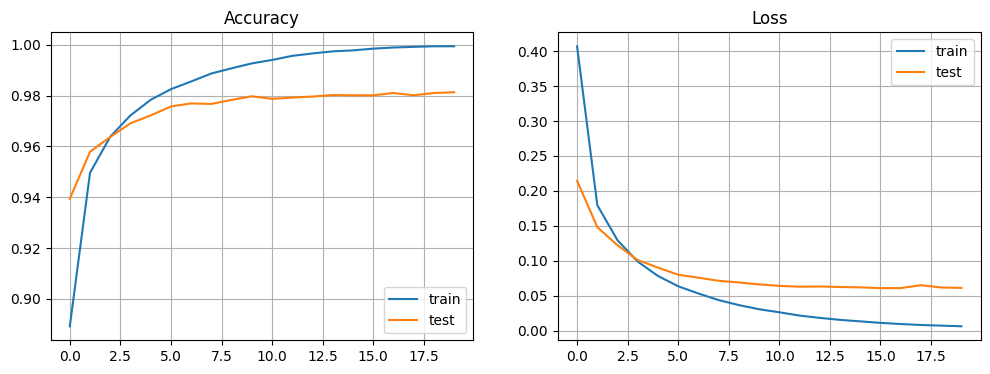

In [94]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,510 (1.52 MB)

 Trainable params: 397,510 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
60/60 - 3s - 52ms/step - accuracy: 0.8498 - loss: 0.5684 - val_accuracy: 0.9225 - val_loss: 0.2687
Epoch 2/20
60/60 - 0s - 6ms/step - accuracy: 0.9347 - loss: 0.2316 - val_accuracy: 0.9458 - val_loss: 0.1936
Epoch 3/20
60/60 - 0s - 6ms/step - accuracy: 0.9499 - loss: 0.1758 - val_accuracy: 0.9538 - val_loss: 0.1602
Epoch 4/20
60/60 - 0s - 6ms/step - accuracy: 0.9613 - loss: 0.1391 - val_accuracy: 0.9625 - val_loss: 0.1315
Epoch 5/20
60/60 - 0s - 6ms/step - accuracy: 0.9691 - loss: 0.1130 - val_accuracy: 0.9669 - val_loss: 0.1126
Epoch 6/20
60/60 - 0s - 6ms/step - accuracy: 0.9738 - loss: 0.0952 - val_accuracy: 0.9698 - val_loss: 0.0999
Epoch 7/20
60/60 - 0s - 6ms/step - accuracy: 0.9783 - loss: 0.0800 - val_accuracy: 0.9720 - val_loss: 0.0909
Epoch 8/20
60/60 - 0s - 6ms/step - accuracy: 0.9807 - loss: 0.0698 - val_accuracy: 0.9750 - val_loss: 0.0846
Epoch 9/20
60/60 - 0s - 6ms/step - accuracy: 0.9843 - loss: 0.0603 - val_accuracy: 0.9766 - val_loss: 0.0800
Epoch 10/20
60/60 

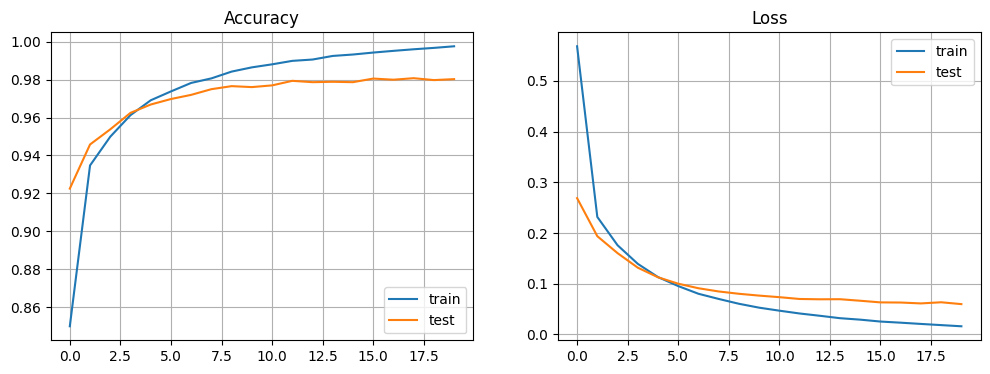

In [95]:
model = ffnn_one_HL(X_train.shape[1], 500 ,y_train_oh.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])

start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 1000,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

Shuffling columns makes the task drastically harder for humans but does not significantly affect a dense neural network’s performance. However, this is not the case for architectures like convolutional neural networks (CNNs), which explicitly depend on spatial relationships. For CNNs, shuffling destroys the locality structure, making the task much more difficult.